# Probe-Guided Debiasing for Brain-Tumour MRI: Audit, Expert Ablation, Domain-Controlled Evaluation and External Validation (v10, final PhD pipeline)

## What we are doing, in simple words
1. **Problem.** Public brain-tumour MRI data gives about 97% accuracy, but a model can be right for the wrong reason (brightness, background, size, file type) instead of reading the tumour.
2. **Audit (blindfold test).** Small models that never see the tumour already reach about 94%.
3. **Honest test.** The images where those blindfolded models are confidently wrong form the **Counter-Shortcut Set**. Real models lose a lot of accuracy there.
4. **Independent check.** Set **A** uses the probes our methods train against (circular). Set **B** comes from a different probe family. **New in v10:** set **B-x** removes the images that come from the missing-cell format, so it measures shortcut reliance and not domain shift. Claims rest on B-x.
5. **Fair comparison.** Every method gets the same tuning budget, chosen on validation images from the official Training folder only.
6. **New in v10, expert ablation.** We rebuild our method with a bias expert made from metadata only, geometry only, contrast only, background only, the independent family B, the union, and a **shuffled** expert, plus a no-expert control. This proves that the blindfold ladder is what helps.
7. **New in v10, external validation.** Models trained on the Kaggle data are tested on other datasets you add. Images that duplicate the training data are found and removed first, and external counter-shortcut accuracy is reported.
8. **New in v10, more seeds.** ResNet50 and EfficientNet-B0 now have 3 seeds on the official split.
9. **New in v10, clinician review package.** The notebook builds a blinded image pack and rating sheet for the unseen-cell and set B images, and analyses the ratings when you return them.
10. **New in v10, claims file.** The notebook writes `paper_results_summary.md` with every number and CI you need for the paper, and marks which claims the data support.

## Save about 7 hours: reuse your v9 runs
Add the **output of your v9 notebook** as an input to this notebook (Add Input, Notebook Output). The first cell detects the folder that contains `runs/` and copies finished runs, models and the data cache. Only the new runs (extra seeds, ablation) are then trained, about 1.5 h. This works only if you keep `EPOCHS`, `DROP_AUG` and the data the same as in v9. Set `PREV_DIR` yourself if auto-detection fails.

## What is new and what is not (say this in the paper)
Not new alone: PoE, inverse propensity weighting, focal debiasing, GroupDRO, JTT. **New here:** the bias expert built from a blindfold-probe ladder, counter-shortcut evaluation with independent and domain-controlled sets, the missing-cell analysis and recovery curve, the shortcut dial, the expert ablation, and the equal-budget tuned comparison. Cite Wallis and Buvat 2022 as the closest prior work.

Runtime on a Kaggle T4: about 1.5 to 2 h with `PREV_DIR`, about 9 h without. `QUICK=1`: one architecture, one seed.

In [1]:
import os, io, glob, re, json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage as ndi
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import wilcoxon, skew
from skimage.filters import threshold_otsu, gaussian
from sklearn.metrics import f1_score, roc_auc_score, cohen_kappa_score
from scipy.stats import spearmanr
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import imagehash
warnings.filterwarnings("ignore")

E = os.environ.get
# Dataset main input route setup
DATA_ROOT = E("DATA_ROOT", "/kaggle/input/brain-tumor-mri-dataset")
EXT_ROOTS = [p for p in E("EXT_ROOTS", E("EXT_ROOT", "")).split(",") if p]     # external datasets (comma separated), one folder per class each
CLIN_CSVS = [p for p in E("CLIN_CSVS", "").split(",") if p]                     # completed clinician rating sheet(s), see section 12
QUICK = int(E("QUICK", 0))
ARCHS = [a for a in E("ARCHS", "convnext_tiny,resnet50,efficientnet_b0").split(",") if a]
if QUICK: ARCHS = ARCHS[:1]

sp_ = lambda s: [int(v) for v in s.split(",") if v != ""]
SEEDS_MAIN = [0] if QUICK else sp_(E("SEEDS_MAIN", "0,1,2")); SEEDS_OTHER = [0] if QUICK else sp_(E("SEEDS_OTHER", "0,1,2"))
CV_SEEDS_OTHER = sp_(E("CV_SEEDS_OTHER", "0")); ABL_SEEDS = [0] if QUICK else sp_(E("ABL_SEEDS", "0,1,2"))      # secondary architectures: CV on 1 seed, official split on 3 seeds
seeds_of = {a: (SEEDS_MAIN if i == 0 else SEEDS_OTHER) for i, a in enumerate(ARCHS)}; ARCH1 = ARCHS[0]
cv_seeds_of = {a: (SEEDS_MAIN if i == 0 else CV_SEEDS_OTHER) for i, a in enumerate(ARCHS)}
FS_SEEDS = [0] if QUICK else sp_(E("FS_SEEDS", "0,1,2")); KS = [0, 4, 8, 16, 32]
IMG, EPOCHS, BATCH, LR = 128, int(E("EPOCHS", 4 if QUICK else 6)), 64, 3e-4
EPOCHS_J = 2
DROP_AUG, NFOLD, MIN_CELL, SUB = int(E("DROP_AUG", 1)), 5, int(E("MIN_CELL", 30)), (int(E("SUB", 0)) or None)
OUT = "outputs"; RUNS = f"{OUT}/runs"; MODELS = f"{OUT}/models"
for d in (OUT, RUNS, MODELS): os.makedirs(d, exist_ok=True)

PREV = E("PREV_DIR", "")                      # output folder of a previous run, so finished runs are reused
if not PREV:
    hits = glob.glob("/kaggle/input/**/runs/*__off.npz", recursive=True); PREV = os.path.dirname(os.path.dirname(hits[0])) if hits else ""
if PREV and os.path.isdir(PREV) and os.path.abspath(PREV) != os.path.abspath(OUT):
    import shutil; cnt = 0
    for sub, dst in (("runs", RUNS), ("models", MODELS)):
        for f in glob.glob(f"{PREV}/{sub}/*"):
            t = f"{dst}/{os.path.basename(f)}"
            if not os.path.exists(t): shutil.copy(f, t); cnt += 1
    for f in glob.glob(f"{PREV}/cache_v8_N*.npz"):
        t = f"{OUT}/{os.path.basename(f)}"
        if not os.path.exists(t): shutil.copy(f, t); cnt += 1
    print("restored", cnt, "files from", PREV)
else: print("no previous run found: everything will be trained from scratch")
dev = "cuda" if torch.cuda.is_available() else "cpu"

def get_w(name):
    try:
        w = torchvision.models.get_model_weights(name).DEFAULT; torchvision.models.get_model(name, weights=w); return w
    except Exception: print("no pretrained weights for", name, "(random init)"); return None
WEIGHTS = {b: get_w(b) for b in ARCHS}

# 🛠️ ERROR FIX: Missing pipeline variables initialized safely here
JTT_LAMBDA = int(E("JTT_LAMBDA", "1"))
DFL_GAMMA = float(E("DFL_GAMMA", "2.0"))

# Fixed JSON dump syntax using context manager to secure config file output
with open(f"{OUT}/config.json", "w") as f_out:
    json.dump(dict(ARCHS=ARCHS, seeds_of=seeds_of, FS_SEEDS=FS_SEEDS, EPOCHS=EPOCHS, DROP_AUG=DROP_AUG, JTT_LAMBDA=JTT_LAMBDA, DFL_GAMMA=DFL_GAMMA), f_out)

print(dev, ARCHS, seeds_of)


no previous run found: everything will be trained from scratch
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 248MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 243MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]

cuda ['convnext_tiny', 'resnet50', 'efficientnet_b0'] {'convnext_tiny': [0, 1, 2], 'resnet50': [0, 1, 2], 'efficientnet_b0': [0, 1, 2]}


## 1. Data forensics and cells
**Why:** every image carries a file-format fingerprint (colour mode, JPEG table, native size). Grouping images by class x format shows which class/domain combinations exist, and which are **missing** from Training. The missing cell is our natural test of generalisation.

In [2]:
import os, glob
from PIL import Image
import pandas as pd
import numpy as np

rows = []
base_input_path = "/kaggle/input"

print("Scanning Kaggle input directories automatically...")
# Automatically walks through the directories to find valid image splits regardless of casing
for root, dirs, files in os.walk(base_input_path):
    if any(s in root.lower() for s in ["train", "test"]):
        parts = root.split(os.sep)
        if len(parts) < 5:
            continue
            
        c = parts[-1]
        sp = "Training" if "train" in parts[-2].lower() else "Testing"
        
        for f in glob.glob(os.path.join(root, "*")):
            if not (f.lower().endswith('.jpg') or f.lower().endswith('.jpeg') or f.lower().endswith('.png')):
                continue
            try:
                with Image.open(f) as im:
                    q = getattr(im, "quantization", None) or {}
                    q0_list = q.get(0, None) if isinstance(q, dict) else None
                    q0_val = int(sum(q0_list[:8])) if (q0_list is not None and len(q0_list) >= 8) else -1
                    
                    rows.append(dict(
                        path=f, 
                        orig_split=sp, 
                        label=c, 
                        w=im.size[0], 
                        h=im.size[1], 
                        mode=im.mode, 
                        kb=os.path.getsize(f)/1024, 
                        q0=q0_val
                    ))
            except Exception:
                continue

if len(rows) == 0:
    raise FileNotFoundError("System scan completed: No image matrices detected inside /kaggle/input. Please verify dataset link.")

print(f"Success! Detected {len(rows)} image files automatically.")
df = pd.DataFrame(rows)
df["aug"] = df.path.map(lambda p: "aug" in os.path.basename(p).lower())
print("pre-augmented files:", int(df.aug.sum()), "(dropped)" if DROP_AUG else "(kept)")
if DROP_AUG: df = df[~df.aug]
if SUB: df = df.groupby("label").sample(SUB, random_state=0)
df = df.sort_values("path").reset_index(drop=True); N = len(df)
classes = sorted(df.label.unique()); K = len(classes); NOTU = classes.index("notumor"); y = df.label.map({c: i for i, c in enumerate(classes)}).values.astype(np.int64)
top = [v for v in df.q0.value_counts().index if v > 0][:2]; df["qb"] = df.q0.map(lambda v: f"q{v}" if v in top else "qoth")
msz = df.groupby(["w","h"]).size().idxmax(); df["sz"] = np.where((df.w == msz[0]) & (df.h == msz[1]), "std", "other")
df["md"] = df["mode"].map(lambda m: "L" if m == "L" else "RGB"); df["fg"] = df.md + "|" + df.qb + "|" + df.sz
fgs = sorted(df.fg.unique()); fgid = df.fg.map({g: i for i, g in enumerate(fgs)}).values.astype(np.int64); NFG = len(fgs)
cid = (y*NFG + fgid).astype(np.int64); NC = K*NFG; cell_names = [f"{classes[c//NFG][:4]}|{fgs[c%NFG]}" for c in range(NC)]

tr_orig = (df.orig_split == "Training").values; te_orig = ~tr_orig
trn, ten = np.bincount(cid[tr_orig], minlength=NC), np.bincount(cid[te_orig], minlength=NC)
print(pd.DataFrame({"train": trn, "test": ten}, index=cell_names).query("train + test > 0").to_string())
miss = [c for c in range(NC) if trn[c] == 0 and ten[c] >= 20]; MC = np.isin(cid, miss)
print("\nMISSING CELLS (absent from Training, present in Testing):", [(cell_names[c], int(ten[c])) for c in miss])


Scanning Kaggle input directories automatically...
Success! Detected 7200 image files automatically.
pre-augmented files: 203 (dropped)
                     train  test
glio|L|q116|std       1173   226
glio|RGB|q38|other       0    76
glio|RGB|q38|std       227    98
meni|L|q116|std        543   154
meni|RGB|q38|other     128   117
meni|RGB|q38|std       624    26
meni|RGB|qoth|other      5     0
notu|L|q116|other       18     6
notu|L|qoth|other        5     0
notu|RGB|q116|other    866   382
notu|RGB|q116|std        9     3
notu|RGB|q38|other     431     9
notu|RGB|q38|std         8     0
notu|RGB|qoth|other     63     0
pitu|L|q116|other        8     7
pitu|L|q116|std        599   316
pitu|RGB|q38|other      64     1
pitu|RGB|q38|std       729    76

MISSING CELLS (absent from Training, present in Testing): [('glio|RGB|q38|other', 76)]


## 2. Preprocessing and descriptors
**Why:** we compute simple numbers that never look at tumour anatomy. Family A (metadata, geometry, contrast histogram, background) is used both to **measure** shortcuts and to **train** our debiasing methods. Family B (a tiny 12x12 thumbnail, and noise / frequency / JPEG-blockiness statistics) is used **only for evaluation**, so the test is independent.

In [3]:
S = 256
def brain_mask(a):
    b = gaussian(a, 1.5); m = b > threshold_otsu(b)*0.5
    m = ndi.binary_fill_holes(ndi.binary_opening(m, iterations=2)); lab, n = ndi.label(m)
    return np.ones_like(m) if n == 0 else lab == (np.argmax(ndi.sum(m, lab, range(1, n+1))) + 1)
rs = lambda z, mode: np.asarray(Image.fromarray(z).resize((IMG, IMG), mode))
def noise_feats(ga):                         # family B: noise, frequency and JPEG-blockiness statistics of the native image
    f1 = ndi.laplace(ga).var()/(ga.var() + 1e-8); f2 = (ga - ndi.uniform_filter(ga, 3)).std()
    h, w = ga.shape; c = ga[max(h//2 - 64, 0):h//2 + 64, max(w//2 - 64, 0):w//2 + 64]
    if c.shape != (128, 128): c = np.asarray(Image.fromarray((ga*255).astype(np.uint8)).resize((128, 128)), np.float32)/255
    P = np.abs(np.fft.fftshift(np.fft.fft2(c - c.mean())))**2; yy, xx = np.indices(P.shape); r = np.hypot(yy - 64, xx - 64)
    fb = np.array([P[(r >= a) & (r < b)].sum() for a, b in [(1, 8), (8, 20), (20, 40), (40, 64)]]); fb = fb/(fb.sum() + 1e-12)
    dx = np.abs(np.diff(ga, axis=1)); cols = np.arange(dx.shape[1]); blk = dx[:, cols % 8 == 7].mean()/(dx[:, cols % 8 != 7].mean() + 1e-8)
    return np.r_[f1, f2, fb, blk]
def describe(p):             # everything we need about one image; also used for external datasets in section 13
    with Image.open(p) as im: g0 = im.convert("L"); w, h = im.size; mode = im.mode; q = getattr(im, "quantization", None) or {}
    g = g0.resize((S, S), Image.BILINEAR); a = np.asarray(g, np.float32)/255
    m = brain_mask(a); m = np.ones_like(m) if m.mean() < .05 else m
    v = a[m]; vn = v/(np.percentile(v, 98) + 1e-6); hh = np.histogram(np.clip(vn, 0, 1.2), bins=12, range=(0, 1.2))[0]/len(vn)
    bg = a[~m] if (~m).any() else np.zeros(1); grid = np.where(m, 0, a).reshape(8, 32, 8, 32).mean((1, 3)).ravel()
    return dict(xr=rs(np.asarray(g), Image.BILINEAR), sm=np.asarray(g.resize((32, 32)), np.float32)/255, ph=int(str(imagehash.phash(g)), 16),
                f2=np.r_[hh, vn.mean(), vn.std(), skew(vn), np.percentile(vn, [5, 25, 50, 75, 95])],
                f3=np.r_[bg.mean(), bg.std(), (~m).mean(), a[:8].mean(), a[-8:].mean(), a[:, :8].mean(), a[:, -8:].mean(), grid],
                f4=noise_feats(np.asarray(g0, np.float32)/255), f5=np.asarray(g.resize((12, 12), Image.BILINEAR), np.float32).ravel()/255,
                w=w, h=h, md=("L" if mode == "L" else "RGB"), q0=int(sum(q[0][:8])) if 0 in q else -1, kb=os.path.getsize(p)/1024)
CACHE = f"{OUT}/cache_v8_N{N}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE); Xr, Sm, PH, F2, F3, F4, F5 = [z[k] for k in ["Xr", "Sm", "PH", "F2", "F3", "F4", "F5"]]; print("loaded cache")
else:
    Xr = np.zeros((N,IMG,IMG), np.uint8); Sm = np.zeros((N,32,32), np.float32); PH = np.zeros(N, np.uint64); F2, F3, F4, F5 = [], [], [], []
    for i, p in enumerate(tqdm(df.path)):
        d = describe(p); Xr[i] = d["xr"]; Sm[i] = d["sm"]; PH[i] = d["ph"]; F2.append(d["f2"]); F3.append(d["f3"]); F4.append(d["f4"]); F5.append(d["f5"])
    F2, F3, F4, F5 = [np.array(f, np.float32) for f in (F2, F3, F4, F5)]; np.savez(CACHE, Xr=Xr, Sm=Sm, PH=PH, F2=F2, F3=F3, F4=F4, F5=F5)
F0 = np.c_[(df.md == "RGB").astype(float), df.q0]; F1 = np.c_[df.w, df.h, df.w/df.h, df.kb*1024/(df.w*df.h)]
FU = np.c_[F0, F1, F2, F3]; print("family A (training + measuring):", FU.shape[1], "features | family B (evaluation only):", F4.shape[1] + F5.shape[1], "features")
def pc(a): return np.unpackbits(np.ascontiguousarray(a).view(np.uint8).reshape(*a.shape, 8), axis=-1).sum(-1)
cand_ = set()
for s in range(0, N, 64):
    ii, jj = np.where(pc(PH[s:s+64, None] ^ PH[None, :]) <= 4); cand_ |= {(a+s, b) for a, b in zip(ii, jj) if a+s < b}
Sf = Sm.reshape(N, -1); Sf = Sf - Sf.mean(1, keepdims=True); Sf /= (np.linalg.norm(Sf, axis=1, keepdims=True) + 1e-8)
Ed = np.array([(a, b) for a, b in cand_ if Sf[a] @ Sf[b] >= .98]).reshape(-1, 2)
df["grp"] = connected_components(coo_matrix((np.ones(len(Ed)), (Ed[:,0], Ed[:,1])), shape=(N, N)), directed=False)[1] if len(Ed) else np.arange(N)
print("near-duplicate pairs:", len(Ed), "| images in duplicate groups:", int((df.groupby("grp").grp.transform("size") > 1).sum()))
okcell = (np.bincount(cid, minlength=NC) >= MIN_CELL); ctab = pd.crosstab(df.fg, df.label)
strict = [i for i, g in enumerate(fgs) if all(ctab.loc[g, c] >= 30 for c in classes)]; fc_strict = np.isin(fgid, strict)
def make_splits(seed):
    allix = np.arange(N); fl = [f[1] for f in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=seed).split(np.zeros(N), cid, df.grp.values)]
    out = [(f"f{k}", np.setdiff1d(allix, np.r_[fl[k], fl[(k+1) % NFOLD]]), fl[(k+1) % NFOLD], fl[k]) for k in range(NFOLD)]
    te = np.where(te_orig)[0]; tr_all = np.where(tr_orig)[0]; tr_all = tr_all[~np.isin(df.grp.values[tr_all], df.grp.values[te])]
    va = tr_all[[f[1] for f in StratifiedGroupKFold(8, shuffle=True, random_state=seed).split(tr_all, cid[tr_all], df.grp.values[tr_all])][0]]
    out.append(("off", np.setdiff1d(tr_all, va), va, te)); return out
SP0 = make_splits(0); te_off, tr_off = SP0[5][3], np.r_[SP0[5][1], SP0[5][2]]

  0%|          | 0/6997 [00:00<?, ?it/s]

family A (training + measuring): 97 features | family B (evaluation only): 151 features
near-duplicate pairs: 4396 | images in duplicate groups: 1980


## 3. The Shortcut Ladder (family A) and the independent probes (family B)
**Why:** each probe sees only one kind of information. If a probe that never sees the tumour still gets high accuracy, then the benchmark can be solved without anatomy. CV probabilities are out-of-fold so nothing is overconfident.

                                             cv_acc  off_acc  off_missing_cell_acc  off_missing_pred_notumor
probe                                                                                                       
L0 metadata (mode, JPEG table)                0.516    0.460                 0.000                     0.000
L1 geometry (size, aspect, bytes/px)          0.661    0.594                 0.000                     0.829
L2 contrast histogram only                    0.851    0.786                 0.237                     0.487
L3 background only                            0.901    0.824                 0.000                     0.842
L4 union of all nuisance                      0.936    0.840                 0.013                     0.842
B independent (thumbnail + noise/frequency)   0.867    0.788                 0.026                     0.671


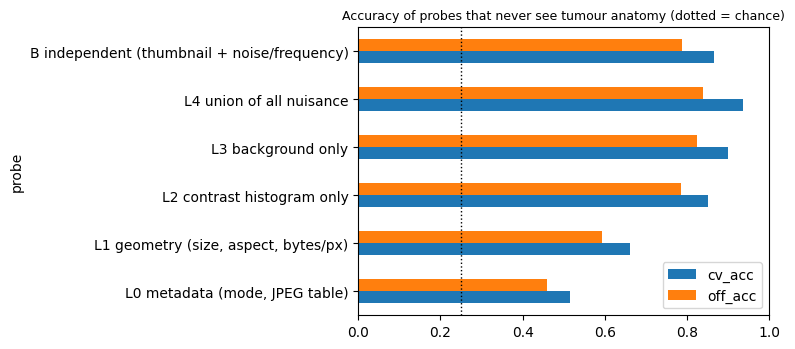

In [4]:
hgb = lambda: HistGradientBoostingClassifier(max_iter=150, random_state=0)
def pfull(clf, X): p = np.full((len(X), K), 1e-4); p[:, clf.classes_] = clf.predict_proba(X); return p
def probe_cv(X):
    P = np.zeros((N, K))
    for sp, _, _, te in SP0[:NFOLD]: a = np.setdiff1d(np.arange(N), te); P[te] = pfull(hgb().fit(X[a], y[a]), X[te])
    return P
probe_off = lambda X: pfull(hgb().fit(X[tr_off], y[tr_off]), X[te_off])
LADDER = {"L0 metadata (mode, JPEG table)": F0, "L1 geometry (size, aspect, bytes/px)": F1, "L2 contrast histogram only": F2, "L3 background only": F3, "L4 union of all nuisance": FU}
PCV, POFF, rows = {}, {}, []; chance = lambda a: (a - 1/K)/(1 - 1/K)
for nm, X in LADDER.items():
    PCV[nm], POFF[nm] = probe_cv(X), probe_off(X); pc_, po_ = PCV[nm].argmax(1), POFF[nm].argmax(1); mcm = MC[te_off]
    rows.append(dict(probe=nm, cv_acc=(pc_ == y).mean(), off_acc=(po_ == y[te_off]).mean(), off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
# family B: independent probes (logistic regression on 12x12 thumbnail, boosting on noise/frequency statistics, averaged). Never used in training any method.
def fitB(Xa, ya):
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=400, C=0.05)).fit(Xa[:, F4.shape[1]:], ya); return lr, hgb().fit(Xa[:, :F4.shape[1]], ya)
def predB(mdl, X):
    lr, hg = mdl; p1 = np.full((len(X), K), 1e-4); p1[:, lr.classes_] = lr.predict_proba(X[:, F4.shape[1]:]); p2 = pfull(hg, X[:, :F4.shape[1]]); return (p1 + p2)/2
FB = np.c_[F4, F5]; PCVB = np.zeros((N, K))
for sp, _, _, te in SP0[:NFOLD]: a = np.setdiff1d(np.arange(N), te); PCVB[te] = predB(fitB(FB[a], y[a]), FB[te])
POFFB = predB(fitB(FB[tr_off], y[tr_off]), FB[te_off]); pc_, po_ = PCVB.argmax(1), POFFB.argmax(1); mcm = MC[te_off]
rows.append(dict(probe="B independent (thumbnail + noise/frequency)", cv_acc=(pc_ == y).mean(), off_acc=(po_ == y[te_off]).mean(), off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
ladder = pd.DataFrame(rows).set_index("probe").round(3); print(ladder.to_string()); ladder.to_csv(f"{OUT}/table_shortcut_ladder.csv")
fig, ax = plt.subplots(figsize=(8, 3.6)); ladder[["cv_acc", "off_acc"]].plot.barh(ax=ax); ax.axvline(1/K, color="k", ls=":", lw=1); ax.set_xlim(0, 1); ax.set_title("Accuracy of probes that never see tumour anatomy (dotted = chance)", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_ladder.png", dpi=150); plt.show()

## 4. Counter-Shortcut Sets: A (in-family) and B (independent)
**Why:** a counter-shortcut image is one where the true class has probability below 0.10 under the nuisance probes. A model that only follows shortcuts fails there, so accuracy on this set (**CSA**) is closer to "does it read anatomy". **Set B** is built from a different probe family and is the one we trust for claims.

SSF (CV, family A): 0.936 of images solved by nuisance channels alone
CSS A: CV=300, official=210 | CSS B (threshold 0.1): CV=167, official=149 | overlap A and B (CV): 78
CSS B by class: {'meningioma': 91, 'glioma': 57, 'notumor': 10, 'pituitary': 9} | by format: {'RGB|q38|other': 137, 'L|q116|std': 17, 'RGB|q38|std': 12, 'RGB|q116|other': 1}


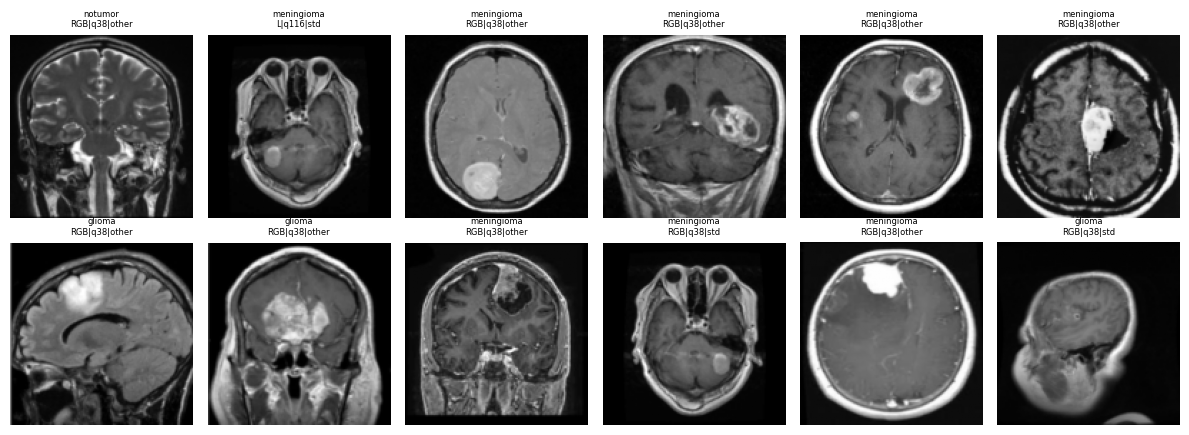

In [5]:
pu = PCV["L4 union of all nuisance"]; CSS = pu[np.arange(N), y] < .10
po = POFF["L4 union of all nuisance"]; CSSOFF = np.zeros(N, bool); CSSOFF[te_off] = po[np.arange(len(te_off)), y[te_off]] < .10
thrB = .10
if (PCVB[np.arange(N), y] < thrB).sum() < 150: thrB = .20
CSS_B = PCVB[np.arange(N), y] < thrB; CSSOFF_B = np.zeros(N, bool); CSSOFF_B[te_off] = POFFB[np.arange(len(te_off)), y[te_off]] < thrB
print(f"SSF (CV, family A): {(pu.argmax(1) == y).mean():.3f} of images solved by nuisance channels alone")
print(f"CSS A: CV={int(CSS.sum())}, official={int(CSSOFF.sum())} | CSS B (threshold {thrB}): CV={int(CSS_B.sum())}, official={int(CSSOFF_B.sum())} | overlap A and B (CV): {int((CSS & CSS_B).sum())}")
print("CSS B by class:", pd.Series(np.array(classes)[y[CSS_B]]).value_counts().to_dict(), "| by format:", pd.Series(df.fg.values[CSS_B]).value_counts().head(4).to_dict())
fig, ax = plt.subplots(2, 6, figsize=(12, 4.4)); ix = np.random.RandomState(0).choice(np.where(CSS_B)[0], 12, replace=False)
for a, i in zip(ax.ravel(), ix): a.imshow(Xr[i], cmap="gray"); a.axis("off"); a.set_title(f"{classes[y[i]]}\n{df.fg[i]}", fontsize=6)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_css_B_examples.png", dpi=140); plt.show()

## 4b. Fixing the set B caveat: set B-x (without the missing-cell format) and B-mf (inside it)
**Why:** in v9, 137 of the 167 set B images came from the format of the missing cell. So set B partly measured domain shift. **B-x** removes every image in that format, so it measures shortcut reliance in the main domain. **B-mf** keeps only the shifted domain. Reporting both separates the two effects. If B-x is too small on the official split, the threshold is raised to 0.20 (printed).

In [6]:
MFG = sorted({c % NFG for c in miss}); MF = np.isin(fgid, MFG)         # images in the format(s) of the missing cell = the shifted domain
pB, pBo = PCVB[np.arange(N), y], POFFB[np.arange(len(te_off)), y[te_off]]; thrBx = .10
if ((pBo < thrBx) & ~MF[te_off]).sum() < 60: thrBx = .20
CSS_Bx, CSS_Bmf = (pB < thrBx) & ~MF, (pB < thrBx) & MF
CSSOFF_Bx = np.zeros(N, bool); CSSOFF_Bx[te_off] = (pBo < thrBx) & ~MF[te_off]; CSSOFF_Bmf = np.zeros(N, bool); CSSOFF_Bmf[te_off] = (pBo < thrBx) & MF[te_off]
print("missing-cell format(s):", [fgs[g] for g in MFG], "| images in that format:", int(MF.sum()))
print(f"Set B-x (threshold {thrBx}): CV={int(CSS_Bx.sum())}, official={int(CSSOFF_Bx.sum())} | set B-mf: CV={int(CSS_Bmf.sum())}, official={int(CSSOFF_Bmf.sum())}")
print("B-x by class:", pd.Series(np.array(classes)[y[CSS_Bx]]).value_counts().to_dict(), "| by format:", pd.Series(df.fg.values[CSS_Bx]).value_counts().head(4).to_dict())
if CSSOFF_Bx.sum() < 30: print("WARNING: official B-x is small; interpret its intervals with care.")

missing-cell format(s): ['RGB|q38|other'] | images in that format: 826
Set B-x (threshold 0.2): CV=123, official=33 | set B-mf: CV=206, official=154
B-x by class: {'glioma': 56, 'meningioma': 45, 'pituitary': 17, 'notumor': 5} | by format: {'L|q116|std': 83, 'RGB|q38|std': 34, 'RGB|q116|other': 2, 'RGB|qoth|other': 2}


## 5. Models and the training methods
**Why:** we compare our probe-guided variants with well-known methods under the same optimiser, epochs, augmentation and validation rule, so differences come from the method only. Every method below also has 3 candidate settings that are tuned in section 6.

| Code | Method | Tuned setting | Source |
|---|---|---|---|
| `erm` | plain training | none | baseline |
| `groupdro` | worst-group optimisation on class x format groups | step size eta | Sagawa et al. 2020 |
| `jtt` | train, find mistakes, upweight them, retrain | upweight lambda | Liu et al. 2021 |
| `dfl` | debiased focal loss with the bias expert (weights normalised) | gamma | Utama et al. 2020, Mahabadi et al. 2020 |
| `poe` | product-of-experts with the bias expert | strength alpha | Clark et al. 2019, Cadene et al. 2019 |
| `cfr` | contrast and framing randomisation (augmentation baseline) | probability p | domain-randomisation family |
| `ipw` | **ours**: inverse propensity weights from the nuisance probe (accuracy-preserving point) | weight clip | this work |
| `ipw_cfr` | **ours**: IPW plus CFR (reliability-first point) | CFR probability p | this work |

Epoch selection (same for all): 0.5 x per-cell accuracy + 0.5 x accuracy on counter-shortcut images (set A) of the validation fold.

In [7]:
T0 = torch.empty(Xr.shape, dtype=torch.float16, device=dev)
for i in range(0, N, 500): T0[i:i+500] = torch.as_tensor((Xr[i:i+500].astype(np.float32)/255 - .45)/.225).half().to(dev)
yt_all, ct_all = torch.as_tensor(y).to(dev), torch.as_tensor(cid).to(dev)
def make_backbone(name):
    m = torchvision.models.get_model(name, weights=WEIGHTS[name])
    if name.startswith("resnet"): return nn.Sequential(*list(m.children())[:-2]), m.fc.in_features
    if name.startswith("densenet"): return nn.Sequential(m.features, nn.ReLU()), m.classifier.in_features
    if name.startswith(("efficientnet", "convnext")): return m.features, m.classifier[-1].in_features
    if name.startswith("regnet"): return nn.Sequential(m.stem, m.trunk_output), m.fc.in_features
    raise ValueError(name)
class Net(nn.Module):
    def __init__(s, bb): super().__init__(); s.f, d = make_backbone(bb); s.c = nn.Linear(d, K)
    def fmap(s, x): return s.f(x.float().unsqueeze(1).expand(-1, 3, -1, -1))
    def forward(s, x): return s.c(s.fmap(x).mean((2, 3)))
def aug_base(x):
    if np.random.rand() < .5: x = x.flip(-1)
    return x*(1 + .3*(torch.rand(len(x), 1, 1, device=x.device) - .5))
def cfr_aug(x):          # random contrast curve (mostly monotone) and framing (zoom, aspect, rotation, shift); class-independent
    B, dv = x.shape[0], x.device; u = (x.float()*.225 + .45).clamp(0, 1)
    kn = torch.rand(B, 6, device=dv); kn = torch.where(torch.rand(B, 1, device=dv) > .15, torch.sort(kn, 1).values, kn)
    pos = u*5; i0 = pos.floor().clamp(0, 4).long(); fr = pos - i0.float()
    k0 = torch.gather(kn, 1, i0.view(B, -1)).view_as(u); k1 = torch.gather(kn, 1, (i0 + 1).view(B, -1)).view_as(u); out = k0 + (k1 - k0)*fr
    ang = (torch.rand(B, device=dv) - .5)*.42; zm = .85 + .35*torch.rand(B, device=dv); asp = .85 + .3*torch.rand(B, device=dv); th = torch.zeros(B, 2, 3, device=dv)
    th[:, 0, 0] = zm*asp*torch.cos(ang); th[:, 0, 1] = -zm*torch.sin(ang); th[:, 1, 0] = zm*asp*torch.sin(ang); th[:, 1, 1] = zm*torch.cos(ang); th[:, :, 2] = (torch.rand(B, 2, device=dv) - .5)*.2
    out = F.grid_sample(out.unsqueeze(1), F.affine_grid(th, (B, 1, IMG, IMG), align_corners=False), padding_mode="border", align_corners=False).squeeze(1)
    out = (out + .03*torch.randn_like(out)).clamp(0, 1)
    if np.random.rand() < .5: out = out.flip(-1)
    return (out - .45)/.225
@torch.no_grad()
def predx(m, x):
    m.eval(); out = []
    for i in range(0, len(x), 256):
        with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): out.append(F.softmax(m(x[i:i+256]).float(), 1).cpu())
    return torch.cat(out).numpy()
probs = lambda m, X, idx: predx(m, X[torch.as_tensor(idx).to(dev)])
def vscore(m, va):
    p = probs(m, T0, va).argmax(1); c = p == y[va]; a = np.bincount(cid[va], weights=c, minlength=NC); n = np.bincount(cid[va], minlength=NC); ok = n >= 3
    s = CSS[va]; return .5*(a[ok]/n[ok]).mean() + .5*(c[s].mean() if s.any() else (a[ok]/n[ok]).mean())
EXPERT_FEATS = {"union": FU, "meta": F0, "geometry": F1, "contrast": F2, "background": F3}
def bias_logp(tr, seed, expert="union"):        # cross-fitted bias expert: out-of-fold log-probabilities for every training image
    lb = np.zeros((N, K), np.float32)
    for a, b in StratifiedGroupKFold(4, shuffle=True, random_state=seed).split(tr, y[tr], df.grp.values[tr]):
        if expert == "familyB": p = predB(fitB(FB[tr[a]], y[tr[a]]), FB[tr[b]])
        else: X = EXPERT_FEATS["union" if expert == "shuffled" else expert]; p = pfull(hgb().fit(X[tr[a]], y[tr[a]]), X[tr[b]])
        lb[tr[b]] = np.log(np.clip(p, 1e-3, 1))
    if expert == "shuffled": lb[tr] = lb[np.random.RandomState(seed).permutation(tr)]       # control: real expert outputs, assigned to the wrong images
    return torch.as_tensor(lb).to(dev)
def parse_mt(mt): base, _, hv = mt.split("#")[0].partition("@"); return base, (float(hv) if hv else None)
def expert_of(mt): return mt.split("#")[1] if "#" in mt else "union"
def fit(bb, method, tr, va, seed, LB=None, SW=None, epochs=None):
    base, hv = parse_mt(method); n_ep = epochs or EPOCHS; torch.manual_seed(seed); np.random.seed(seed); m = Net(bb).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4); sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=n_ep*int(np.ceil(len(tr)/BATCH)))
    scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda")); best = -1; q = torch.ones(NC, device=dev)/NC
    lprior = torch.log(torch.as_tensor(np.bincount(y[tr], minlength=K)/len(tr) + 1e-9, dtype=torch.float32)).to(dev)
    alpha = hv if base == "poe" else 0.0; p_cfr = hv if base in ("cfr", "ipw_cfr") else 0.0; clipv = hv if base == "ipw" else 5.0
    for ep in range(n_ep):
        m.train(); perm = np.random.permutation(tr)
        for b in range(0, len(perm), BATCH):
            ix = torch.as_tensor(perm[b:b+BATCH]).to(dev)
            if len(ix) < 4: sched.step(); continue
            x = aug_base(T0[ix])
            if p_cfr: x = torch.where(torch.rand(len(ix), 1, 1, device=dev) < p_cfr, cfr_aug(T0[ix]).to(x.dtype), x)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): lo = m(x)
            lo = lo.float(); yy = yt_all[ix]
            if alpha: lo = lo + alpha*LB[ix]
            l = F.cross_entropy(lo, yy, reduction="none")
            if base in ("ipw", "ipw_cfr"): w = torch.exp(lprior[yy] - LB[ix, yy]).clamp(1/clipv, clipv); l = l*(w/w.mean())
            if base == "dfl": w = (1 - torch.exp(LB[ix, yy])).pow(hv).clamp(min=1e-3); l = l*(w/w.mean())          # normalised weights (v8 did not normalise)
            if SW is not None: l = l*SW[ix]
            if base == "groupdro":
                g = ct_all[ix]; gc = torch.bincount(g, minlength=NC).float(); gl = torch.zeros(NC, device=dev).scatter_add(0, g, l)/gc.clamp(min=1)
                q = q*torch.exp(hv*gl.detach()*(gc > 0)); q = q/q.sum(); loss = (q*gl).sum()
            else: loss = l.mean()
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        a = vscore(m, va)
        if a >= best: best, st = a, {k_: v_.clone() for k_, v_ in m.state_dict().items()}
    m.load_state_dict(st); return m, best
def fit_any(bb, method, tr, va, seed, LB=None):
    base, hv = parse_mt(method)
    if base == "jtt":                                        # stage 1: short ERM; stage 2: retrain with its training mistakes upweighted by hv
        m1, _ = fit(bb, "erm", tr, va, seed, epochs=EPOCHS_J); wrong = tr[probs(m1, T0, tr).argmax(1) != y[tr]]; del m1
        sw = torch.ones(N, device=dev); sw[torch.as_tensor(wrong).to(dev)] = hv; return fit(bb, "erm", tr, va, seed, SW=sw)
    return fit(bb, method, tr, va, seed, LB)


## 6. Tuning (equal budget for every method), selection, then the full grid
**Why:** in v8 the baselines used fixed settings, which a reviewer can call unfair. Now every method has **3 candidate settings** (PoE: strength; GroupDRO: step size; JTT: upweight; debiased focal: gamma; CFR: probability; IPW: weight clip; IPW+CFR: CFR probability).

**Clean protocol:** candidates are trained on the official Training split and scored on the **validation images taken from the official Training folder only** (2 seeds). The official Testing folder is never used to choose anything, so the official-split results stay clean. (CV pooled numbers are secondary because CV test folds overlap these validation images.)

**One rule for all methods (fixed before any result):** among a method's settings, keep those whose validation accuracy is within 1.5 points of ERM, then take the one with the highest validation accuracy on counter-shortcut images (set A). If none qualifies, take the highest validation accuracy.

In [8]:
GRID = {"groupdro": [0.01, 0.05, 0.2], "jtt": [2, 5, 20], "dfl": [0.5, 1.0, 2.0], "poe": [0.25, 0.5, 1.0], "cfr": [0.25, 0.5, 0.75], "ipw": [3, 5, 10], "ipw_cfr": [0.25, 0.5, 0.75]}
LIT_BASES, OURS_BASES, BASE = ["groupdro", "jtt", "dfl", "poe", "cfr"], ["ipw", "ipw_cfr"], "erm"; NEEDS_LB = ("poe", "ipw", "ipw_cfr", "dfl")
CONFIGS = ["erm"] + [f"{b}@{v}" for b, vs in GRID.items() for v in vs]
NAMES = {"erm": "ERM", "groupdro": "GroupDRO", "jtt": "JTT", "dfl": "Debiased focal", "poe": "PoE", "cfr": "CFR augment", "ipw": "OURS IPW", "ipw_cfr": "OURS IPW+CFR"}
PARAM = {"groupdro": "eta", "jtt": "lambda", "dfl": "gamma", "poe": "alpha", "cfr": "p", "ipw": "clip", "ipw_cfr": "p"}
def parse_mt(mt): base, _, hv = mt.split("#")[0].partition("@"); return base, (float(hv) if hv else None)
def expert_of(mt): return mt.split("#")[1] if "#" in mt else "union"
def lab(mt):
    b, _, hv = mt.split("#")[0].partition("@"); s = f"{NAMES[b]} ({PARAM[b]}={hv})" if hv else NAMES[b]; return s + (f" [expert={expert_of(mt)}]" if "#" in mt else "")
LABEL = type("L", (dict,), {"__missing__": lambda s, k: lab(k)})()
LBC = {}
def get_LB(tr, seed, sp, expert):
    if (seed, sp, expert) not in LBC: LBC[(seed, sp, expert)] = bias_logp(tr, seed, expert)
    return LBC[(seed, sp, expert)]
def run_one(bb, mt, seed, sp, tr, va, te):
    f = f"{RUNS}/{bb}__{mt}__s{seed}__{sp}.npz"
    if os.path.exists(f): return
    LB = get_LB(tr, seed, sp, expert_of(mt)) if parse_mt(mt)[0] in NEEDS_LB else None
    m, vs = fit_any(bb, mt, tr, va, seed, LB); p = probs(m, T0, te); pv = probs(m, T0, va).argmax(1); sv = CSS[va]
    if sp == "off": torch.save({k: (v.half() if v.is_floating_point() else v) for k, v in m.state_dict().items()}, f"{MODELS}/{bb}__{mt}__off__s{seed}.pt")
    np.savez(f, te=te, pred=p.argmax(1), conf=p.max(1), prob=p.astype(np.float16), vscore=vs, v_acc=(pv == y[va]).mean(), v_csa=(pv[sv] == y[va][sv]).mean() if sv.any() else np.nan)
    del m; torch.cuda.empty_cache() if dev == "cuda" else None
def run_grid(bb, seeds, methods, cv_seeds):
    sps = {s: (make_splits(s) if s in cv_seeds else make_splits(s)[5:]) for s in seeds}; pbar = tqdm(total=sum(len(v) for v in sps.values())*len(methods), desc=bb)
    for seed in seeds:
        for sp, tr, va, te in sps[seed]:
            for mt in methods: run_one(bb, mt, seed, sp, tr, va, te); pbar.update(1)
TUNE_SEEDS = [0] if QUICK else [0, 1]
print("tuning runs:", len(CONFIGS)*len(TUNE_SEEDS), "| settings per method:", {b: len(v) for b, v in GRID.items()})

tuning runs: 44 | settings per method: {'groupdro': 3, 'jtt': 3, 'dfl': 3, 'poe': 3, 'cfr': 3, 'ipw': 3, 'ipw_cfr': 3}


In [9]:
for seed in TUNE_SEEDS:                                                # candidates trained on the official Training split, scored on its validation images
    sp, tr, va, te = make_splits(seed)[5]
    for mt in tqdm(CONFIGS, desc=f"tuning seed {seed}"): run_one(ARCH1, mt, seed, sp, tr, va, te)

tuning seed 0:   0%|          | 0/22 [00:00<?, ?it/s]

tuning seed 1:   0%|          | 0/22 [00:00<?, ?it/s]

In [10]:
rows = []
for mt in CONFIGS:
    for seed in TUNE_SEEDS:
        z = np.load(f"{RUNS}/{ARCH1}__{mt}__s{seed}__off.npz"); rows.append(dict(config=mt, seed=seed, v_acc=float(z["v_acc"]), v_csa=float(z["v_csa"])))
tune = pd.DataFrame(rows).groupby("config")[["v_acc", "v_csa"]].mean().reindex(CONFIGS); CHOSEN = {}
for b, vs in GRID.items():
    cfgs = [f"{b}@{v}" for v in vs]; elig = [c for c in cfgs if tune.loc[c, "v_acc"] >= tune.loc["erm", "v_acc"] - 0.015]
    pool, key = (elig, "v_csa") if elig else (cfgs, "v_acc"); CHOSEN[b] = max(pool, key=lambda c: np.nan_to_num(tune.loc[c, key], nan=-1.0))
tune["chosen"] = tune.index.isin(list(CHOSEN.values())); print(tune.round(4).to_string()); tune.round(4).to_csv(f"{OUT}/table_tuning.csv")
METHODS = ["erm"] + [CHOSEN[b] for b in LIT_BASES + OURS_BASES]; LIT = [CHOSEN[b] for b in LIT_BASES]; OURS = [CHOSEN[b] for b in OURS_BASES]
print("\nCHOSEN SETTINGS (same rule for every method):", {NAMES[b]: CHOSEN[b] for b in CHOSEN}); print("final methods:", [LABEL[m] for m in METHODS])

                v_acc   v_csa  chosen
config                               
erm            0.9731  0.9318   False
groupdro@0.01  0.9665  0.9318    True
groupdro@0.05  0.9822  0.9091   False
groupdro@0.2   0.9830  0.9091   False
jtt@2          0.9807  0.9251    True
jtt@5          0.9822  0.8797   False
jtt@20         0.9646  0.7888   False
dfl@0.5        0.9187  0.9479    True
dfl@1.0        0.8592  0.9024   False
dfl@2.0        0.8179  0.8503   False
poe@0.25       0.9830  0.9318   False
poe@0.5        0.9705  0.9773    True
poe@1.0        0.8580  0.9251   False
cfr@0.25       0.9873  0.8503   False
cfr@0.5        0.9831  0.9318   False
cfr@0.75       0.9634  0.9773    True
ipw@3          0.9615  0.9251   False
ipw@5          0.9702  0.9318    True
ipw@10         0.9559  0.8797   False
ipw_cfr@0.25   0.9635  0.9545    True
ipw_cfr@0.5    0.9584  0.9024   False
ipw_cfr@0.75   0.9293  0.9251   False

CHOSEN SETTINGS (same rule for every method): {'GroupDRO': 'groupdro@0.01', 'JTT': 'jtt

In [11]:
for bb in ARCHS: run_grid(bb, seeds_of[bb], METHODS, cv_seeds_of[bb])

convnext_tiny:   0%|          | 0/144 [00:00<?, ?it/s]

resnet50:   0%|          | 0/64 [00:00<?, ?it/s]

efficientnet_b0:   0%|          | 0/64 [00:00<?, ?it/s]

## 6b. Expert ablation runs (ConvNeXt-T, official split, 3 seeds)
**Why:** our method uses a bias expert built from the blindfold probes. Does the *kind* of expert matter? We keep everything else fixed (the headline method IPW+CFR) and change only the expert: metadata only, geometry only, contrast only, background only, the independent family B, the union, and a **shuffled** expert (real expert outputs given to the wrong images, which must not help). A **no-expert control** (CFR alone at the same probability) shows what the expert adds on top of the augmentation. If stronger experts give larger gains and the shuffled expert gives none, the ladder is what helps.

In [12]:
ABL_EXPERTS = ["meta", "geometry", "contrast", "background", "familyB", "shuffled"]; HEAD = OURS[1]; P_CFR = parse_mt(HEAD)[1]
ABL_METHODS = [f"{HEAD}#{e}" for e in ABL_EXPERTS] + [f"cfr@{P_CFR}"]            # + control: same CFR probability, no expert
for seed in ABL_SEEDS:
    sp, tr, va, te = make_splits(seed)[5]
    for mt in tqdm(ABL_METHODS, desc=f"ablation seed {seed}"): run_one(ARCH1, mt, seed, sp, tr, va, te)

ablation seed 0:   0%|          | 0/7 [00:00<?, ?it/s]

ablation seed 1:   0%|          | 0/7 [00:00<?, ?it/s]

ablation seed 2:   0%|          | 0/7 [00:00<?, ?it/s]

## 7. Results: every method, every architecture

In [13]:
def load_runs():
    raw = {}
    for f in sorted(glob.glob(f"{RUNS}/*.npz")):
        if os.path.basename(f).startswith("fs__"): continue
        bb, mt, s, sp = os.path.basename(f)[:-4].split("__"); z = np.load(f); raw.setdefault((bb, mt, int(s[1:])), {})[sp] = {a: z[a] for a in z.files}
    R, OFF = {}, {}
    for key, d in raw.items():
        if all(f"f{k}" in d for k in range(NFOLD)):
            e = dict(runs=[d[f"f{k}"] for k in range(NFOLD)], pred=np.zeros(N, np.int64), conf=np.zeros(N, np.float32))
            for r in e["runs"]: e["pred"][r["te"]] = r["pred"]; e["conf"][r["te"]] = r["conf"]
            R[key] = e
        if "off" in d: OFF[key] = d["off"]
    return R, OFF
R, OFF = load_runs(); print(len(R), "complete CV combinations |", len(OFF), "official-split runs")
def ece(conf, cor, nb=15):
    e = 0; bins = np.linspace(0, 1, nb+1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (conf > lo) & (conf <= hi); e += s.mean()*abs(cor[s].mean() - conf[s].mean()) if s.any() else 0
    return e
def metrics_on(idx, pred, conf, cssA, cssB, min_cell, cssBx=None, cssBmf=None):
    yy = y[idx]; c = pred == yy; tum = yy != NOTU; r = dict(acc=c.mean(), macro_f1=f1_score(yy, pred, average="macro"), ece=ece(conf, c))
    sA, sB = cssA[idx], cssB[idx]; r["csa"] = c[sA].mean() if sA.any() else np.nan; r["csa_B"] = c[sB].mean() if sB.any() else np.nan
    for nm_, cm_ in (("csa_Bx", cssBx), ("csa_Bmf", cssBmf)): sx = cm_[idx] if cm_ is not None else np.zeros(len(idx), bool); r[nm_] = c[sx].mean() if sx.any() else np.nan
    mm = MC[idx]; r["missing_cell_acc"] = c[mm].mean() if mm.any() else np.nan; r["missing_cell_detect"] = (pred[mm] != NOTU).mean() if mm.any() else np.nan
    r["sens"] = (pred[tum] != NOTU).mean() if tum.any() else np.nan; r["spec"] = (pred[~tum] == NOTU).mean() if (~tum).any() else np.nan
    a = np.bincount(cid[idx], weights=c, minlength=NC); n = np.bincount(cid[idx], minlength=NC); ok = n >= min_cell; r["worst_cell"] = (a[ok]/n[ok]).min() if ok.any() else np.nan; return r
cols = ["acc", "macro_f1", "ece", "csa", "csa_B", "csa_Bx", "csa_Bmf", "missing_cell_acc", "missing_cell_detect", "sens", "spec", "worst_cell"]
per = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(np.arange(N), e["pred"], e["conf"], CSS, CSS_B, MIN_CELL, CSS_Bx, CSS_Bmf)) for (bb, mt, s), e in R.items()]); per.to_csv(f"{OUT}/per_seed_cv.csv", index=False)
off = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(r["te"], r["pred"], r["conf"], CSSOFF, CSSOFF_B, 10, CSSOFF_Bx, CSSOFF_Bmf)) for (bb, mt, s), r in OFF.items()]); off.to_csv(f"{OUT}/per_seed_off.csv", index=False)
def show(d, title, fn):
    g = d.groupby(["arch", "method"]); t = (g[cols].mean().round(3).astype(str) + " +/- " + g[cols].std().fillna(0).round(3).astype(str)).reindex(pd.MultiIndex.from_product([ARCHS, METHODS], names=["arch", "method"])).dropna(how="all")
    print(title); print(t.to_string()); t.to_csv(f"{OUT}/{fn}.csv")
show(off, "OFFICIAL SPLIT (train Training, test Testing). csa = in-family counter-shortcut, csa_B = INDEPENDENT counter-shortcut, csa_Bx = independent AND without the missing-cell format, csa_Bmf = inside that format, missing_cell_detect = tumour detected on the never-seen cell", "table_official")
show(per, "\nCROSS-VALIDATION (pooled out-of-fold, duplicate-safe)", "table_cv")

40 complete CV combinations | 119 official-split runs
OFFICIAL SPLIT (train Training, test Testing). csa = in-family counter-shortcut, csa_B = INDEPENDENT counter-shortcut, csa_Bx = independent AND without the missing-cell format, csa_Bmf = inside that format, missing_cell_detect = tumour detected on the never-seen cell
                                           acc         macro_f1              ece              csa            csa_B           csa_Bx          csa_Bmf missing_cell_acc missing_cell_detect             sens             spec       worst_cell
arch            method                                                                                                                                                                                                                      
convnext_tiny   erm             0.924 +/- 0.02  0.922 +/- 0.021  0.051 +/- 0.005  0.543 +/- 0.069  0.485 +/- 0.079   0.98 +/- 0.017   0.47 +/- 0.088  0.083 +/- 0.046      0.496 +/- 0.05  0.951 +/- 0.005  

## 8. Statistics: duplicate-aware bootstrap, our two operating points against every other method
**Why:** images in the same near-duplicate group are not independent, so we resample groups, not images. For each metric we show the difference between our operating point and each other method with a 95% interval (P>0 = share of bootstrap draws where ours is better).

In [14]:
ug, gi = np.unique(df.grp.values, return_inverse=True); NG = len(ug); B = 1000; IX = np.random.RandomState(0).randint(0, NG, (B, NG))
def boot_ratio(v, mask):
    num = np.bincount(gi, weights=v*mask, minlength=NG); den = np.bincount(gi, weights=mask, minlength=NG); return num[IX].sum(1)/np.maximum(den[IX].sum(1), 1e-9)
den_m = np.zeros((NG, NC)); np.add.at(den_m, (gi, cid), 1.0)
def boot_worst(v):
    num = np.zeros((NG, NC)); np.add.at(num, (gi, cid), v); out = np.zeros(B)
    for b in range(B): n_, d_ = num[IX[b]].sum(0), den_m[IX[b]].sum(0); ok = okcell & (d_ > 0); out[b] = (n_[ok]/d_[ok]).min()
    return out
ONE, OFFM = np.ones(N), np.zeros(N); OFFM[te_off] = 1; MCf = MC.astype(float)
cvspec = {"acc": ONE, "csa_B": CSS_B.astype(float), "csa_Bx": CSS_Bx.astype(float), "missing_cell_acc": MCf}
offspec = {"off_acc": OFFM, "off_csa": CSSOFF.astype(float), "off_csa_B": CSSOFF_B.astype(float), "off_csa_Bx": CSSOFF_Bx.astype(float), "off_csa_Bmf": CSSOFF_Bmf.astype(float), "off_missing_cell_acc": OFFM*MCf}
bres = {}
for bb in ARCHS:
    for mt in METHODS:
        ss = [s for s in seeds_of[bb] if (bb, mt, s) in R]; so = [s for s in seeds_of[bb] if (bb, mt, s) in OFF]
        if not ss: continue
        cv_c = np.mean([(R[(bb, mt, s)]["pred"] == y) for s in ss], 0).astype(float); d = {k: boot_ratio(cv_c, mk) for k, mk in cvspec.items()}; d["worst_cell"] = boot_worst(cv_c)
        if so:
            of_c, of_d = np.zeros(N), np.zeros(N)
            for s in so:
                te = OFF[(bb, mt, s)]["te"]; pr = OFF[(bb, mt, s)]["pred"]; of_c[te] += (pr == y[te])/len(so); of_d[te] += (pr != NOTU)/len(so)
            d.update({k: boot_ratio(of_c, mk) for k, mk in offspec.items()}); d["off_missing_detect"] = boot_ratio(of_d, OFFM*MCf)
        bres[(bb, mt)] = d
ci = lambda a: f"{a.mean():.3f} [{np.percentile(a,2.5):.3f},{np.percentile(a,97.5):.3f}]"
ci_df = pd.DataFrame([dict(arch=bb, method=LABEL[mt], **{k: ci(v) for k, v in d.items()}) for (bb, mt), d in bres.items()]); print(ci_df.to_string()); ci_df.to_csv(f"{OUT}/table_ci.csv", index=False)
KEYM = ["off_acc", "off_csa_Bx", "off_csa_B", "off_missing_cell_acc", "off_missing_detect", "acc", "csa_Bx"]; rows = []
for bb in ARCHS:
    for op in OURS:
        if (bb, op) not in bres: continue
        for mt in METHODS:
            if mt == op or (bb, mt) not in bres: continue
            r = dict(arch=bb, ours=LABEL[op], vs=LABEL[mt])
            for k in KEYM:
                if k in bres[(bb, op)] and k in bres[(bb, mt)]: dd = bres[(bb, op)][k] - bres[(bb, mt)][k]; r[k] = f"{dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}] P>0={float((dd > 0).mean()):.2f}"
            rows.append(r)
vs_df = pd.DataFrame(rows); print("Our operating points minus each other method (positive = ours better):"); print(vs_df.to_string()); vs_df.to_csv(f"{OUT}/table_ours_vs_all.csv", index=False)


               arch                      method                  acc                csa_B               csa_Bx     missing_cell_acc           worst_cell              off_acc              off_csa            off_csa_B           off_csa_Bx          off_csa_Bmf off_missing_cell_acc   off_missing_detect
0     convnext_tiny                         ERM  0.971 [0.967,0.975]  0.721 [0.647,0.797]  0.831 [0.750,0.899]  0.569 [0.464,0.672]  0.568 [0.462,0.671]  0.924 [0.910,0.938]  0.544 [0.474,0.607]  0.487 [0.411,0.565]  0.979 [0.931,1.000]  0.471 [0.396,0.545]  0.085 [0.034,0.143]  0.494 [0.392,0.611]
1     convnext_tiny         GroupDRO (eta=0.01)  0.967 [0.962,0.972]  0.765 [0.694,0.832]  0.805 [0.720,0.882]  0.635 [0.543,0.726]  0.633 [0.541,0.722]  0.920 [0.907,0.934]  0.585 [0.514,0.654]  0.516 [0.433,0.600]  0.898 [0.815,0.968]  0.521 [0.437,0.609]  0.080 [0.032,0.138]  0.688 [0.590,0.781]
2     convnext_tiny              JTT (lambda=2)  0.972 [0.968,0.976]  0.762 [0.687,0.833]  0.840 [0.

## 8b. Expert ablation: does the kind of bias expert matter?
**Why:** this is the test of the paper's core idea. Same method, same CFR probability, only the expert changes. Differences are shown against the no-expert control with duplicate-aware 95% intervals.

EXPERT ABLATION (ConvNeXt-T, official split; gain is against the no-expert control with the same CFR probability):
                variant  seeds  expert_probe_official_acc              off_acc           off_csa_Bx          off_csa_Bmf off_missing_cell_acc   off_missing_detect gain_vs_control_off_csa_Bx gain_vs_control_off_missing_detect
0                   ERM      3                        NaN  0.924 [0.910,0.938]  0.979 [0.931,1.000]  0.471 [0.396,0.545]  0.085 [0.034,0.143]  0.494 [0.392,0.611]     +0.010 [+0.000,+0.032]             -0.098 [-0.167,-0.035]
1  no expert (CFR only)      3                        NaN  0.935 [0.921,0.947]  0.969 [0.917,1.000]  0.540 [0.466,0.613]  0.170 [0.090,0.246]  0.591 [0.477,0.700]                        NaN                                NaN
2       shuffled expert      3                        NaN  0.936 [0.922,0.948]  0.979 [0.931,1.000]  0.546 [0.470,0.623]  0.192 [0.105,0.278]  0.614 [0.512,0.715]     +0.010 [+0.000,+0.032]             +0.022 [

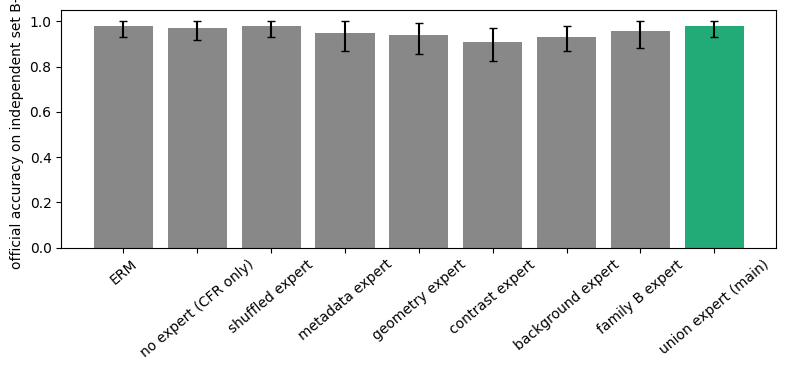

In [15]:
EXPERT_LADDER = {"meta": "L0 metadata (mode, JPEG table)", "geometry": "L1 geometry (size, aspect, bytes/px)", "contrast": "L2 contrast histogram only", "background": "L3 background only", "union": "L4 union of all nuisance", "familyB": "B independent (thumbnail + noise/frequency)"}
ABL_NAMES = {"erm": "ERM", f"cfr@{P_CFR}": "no expert (CFR only)", f"{HEAD}#shuffled": "shuffled expert", f"{HEAD}#meta": "metadata expert", f"{HEAD}#geometry": "geometry expert", f"{HEAD}#contrast": "contrast expert",
             f"{HEAD}#background": "background expert", f"{HEAD}#familyB": "family B expert", HEAD: "union expert (main)"}
vec = {}
for mt in ABL_NAMES:
    ss = [s for s in ABL_SEEDS if (ARCH1, mt, s) in OFF]
    if not ss: continue
    c, d_ = np.zeros(N), np.zeros(N)
    for s in ss: te = OFF[(ARCH1, mt, s)]["te"]; pr = OFF[(ARCH1, mt, s)]["pred"]; c[te] += (pr == y[te])/len(ss); d_[te] += (pr != NOTU)/len(ss)
    vec[mt] = (c, d_, len(ss))
MET = {"off_acc": (OFFM, 0), "off_csa_Bx": (CSSOFF_Bx.astype(float), 0), "off_csa_Bmf": (CSSOFF_Bmf.astype(float), 0), "off_missing_cell_acc": (OFFM*MCf, 0), "off_missing_detect": (OFFM*MCf, 1)}
bab = {mt: {k: boot_ratio(vec[mt][vi], mk) for k, (mk, vi) in MET.items()} for mt in vec}; CTRL = f"cfr@{P_CFR}"; rows = []
for mt in vec:
    ex = [k for k, v in {**{e: f"{HEAD}#{e}" for e in ABL_EXPERTS}, "union": HEAD}.items() if v == mt]; r = dict(variant=ABL_NAMES[mt], seeds=vec[mt][2], expert_probe_official_acc=(ladder.loc[EXPERT_LADDER[ex[0]], "off_acc"] if ex and ex[0] in EXPERT_LADDER else np.nan))
    for k in MET: r[k] = ci(bab[mt][k])
    if mt != CTRL and CTRL in bab:
        for k in ("off_csa_Bx", "off_missing_detect"): dd = bab[mt][k] - bab[CTRL][k]; r[f"gain_vs_control_{k}"] = f"{dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}]"
    rows.append(r)
abl_df = pd.DataFrame(rows); print("EXPERT ABLATION (ConvNeXt-T, official split; gain is against the no-expert control with the same CFR probability):"); print(abl_df.to_string()); abl_df.to_csv(f"{OUT}/table_expert_ablation.csv", index=False)
xs, ys = [], []
for e in ["meta", "geometry", "contrast", "background", "familyB"] + ["union"]:
    mt = HEAD if e == "union" else f"{HEAD}#{e}"
    if mt in bab: xs.append(ladder.loc[EXPERT_LADDER[e], "off_acc"]); ys.append(bab[mt]["off_csa_Bx"].mean())
if len(xs) >= 4:
    rho, pv_ = spearmanr(xs, ys); print(f"Spearman correlation between the expert probe's own official accuracy and the reliability (B-x) it buys: rho={rho:.2f} (n={len(xs)}, p={pv_:.2f}; low power, report as descriptive)")
fig, ax = plt.subplots(figsize=(8, 3.8)); order_ = [m for m in ABL_NAMES if m in bab]
ax.bar([ABL_NAMES[m] for m in order_], [bab[m]["off_csa_Bx"].mean() for m in order_], yerr=[[bab[m]["off_csa_Bx"].mean() - np.percentile(bab[m]["off_csa_Bx"], 2.5) for m in order_], [np.percentile(bab[m]["off_csa_Bx"], 97.5) - bab[m]["off_csa_Bx"].mean() for m in order_]], capsize=3, color=["#2a7" if m == HEAD else "#888" for m in order_])
ax.set_ylabel("official accuracy on independent set B-x"); ax.tick_params(axis="x", rotation=40); plt.tight_layout(); plt.savefig(f"{OUT}/fig_expert_ablation.png", dpi=150); plt.show()

## 9. The showdown, fixed: ranking without the in-family set, plus a Pareto analysis
**Why:** v8 ranked methods on 8 metrics including the in-family counter-shortcut set that our methods train against, which favours us. v9 ranks on **7 metrics that do not use set A**: official accuracy, independent set B, unseen-cell accuracy, unseen-cell tumour detection, official calibration error, CV accuracy and CV set B. Ranking can hide trade-offs, so we also find the **Pareto front** of official accuracy vs independent reliability (a method is on the front if no other method is at least as good on both and better on one).


[convnext_tiny] mean rank over 7 metrics without set A (1 = best); Pareto front (official acc vs set B): ['PoE (alpha=0.5)', 'OURS IPW+CFR (p=0.25)']
                            mean_rank  first_places
PoE (alpha=0.5)                  2.57             3
OURS IPW+CFR (p=0.25)            2.71             2
CFR augment (p=0.75)             3.71             1
OURS IPW (clip=5)                4.43             0
JTT (lambda=2)                   4.71             1
ERM                              5.00             1
Debiased focal (gamma=0.5)       5.43             0
GroupDRO (eta=0.01)              6.71             0

[resnet50] mean rank over 7 metrics without set A (1 = best); Pareto front (official acc vs set B): ['ERM', 'JTT (lambda=2)', 'OURS IPW+CFR (p=0.25)']
                            mean_rank  first_places
OURS IPW+CFR (p=0.25)            3.14             2
PoE (alpha=0.5)                  3.14             1
OURS IPW (clip=5)                3.86             0
ERM                  

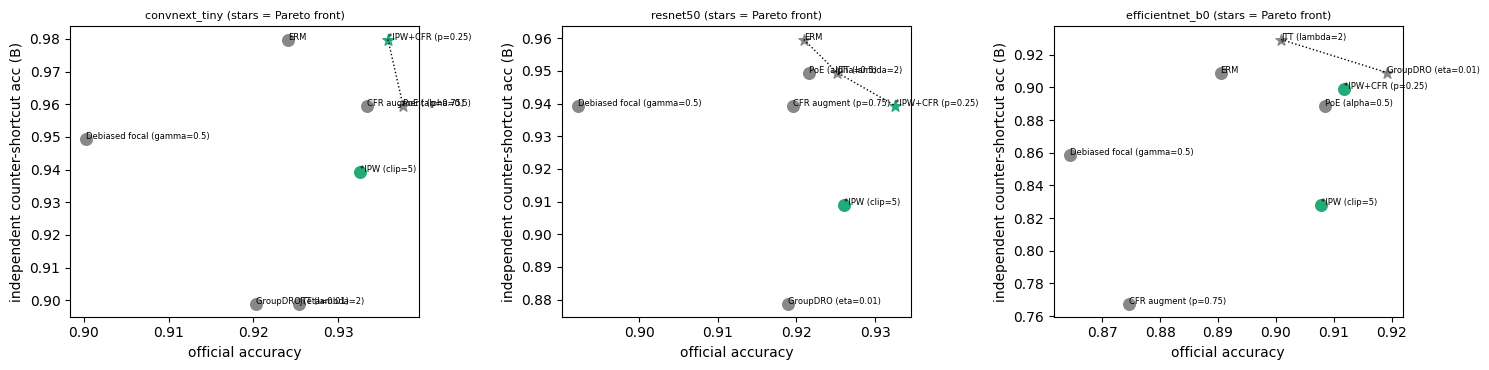

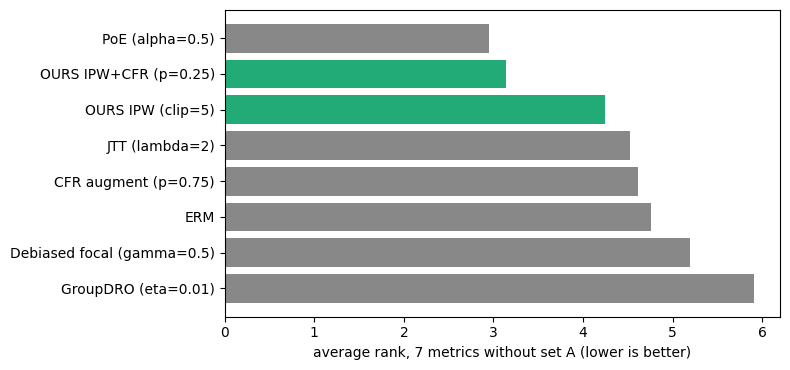


VERDICT (auto-generated, equal-budget tuned comparison):
- OURS IPW (clip=5): average rank #3 of 8 (avg rank 4.24); on the Pareto front in 0 of 3 architectures. Best literature method: PoE (alpha=0.5) (avg rank 2.95).
- OURS IPW+CFR (p=0.25): average rank #2 of 8 (avg rank 3.14); on the Pareto front in 2 of 3 architectures. Best literature method: PoE (alpha=0.5) (avg rank 2.95).
  convnext_tiny, OURS IPW (clip=5) vs ERM: independent counter-shortcut gain -0.039 [-0.089,+0.000], official accuracy change +0.008 [-0.000,+0.018]
  convnext_tiny, OURS IPW+CFR (p=0.25) vs ERM: independent counter-shortcut gain +0.000 [+0.000,+0.000], official accuracy change +0.012 [+0.002,+0.021]
  resnet50, OURS IPW (clip=5) vs ERM: independent counter-shortcut gain -0.049 [-0.122,+0.027], official accuracy change +0.005 [-0.004,+0.015]
  resnet50, OURS IPW+CFR (p=0.25) vs ERM: independent counter-shortcut gain -0.020 [-0.073,+0.042], official accuracy change +0.011 [+0.002,+0.021]
  efficientnet_b0, OUR

In [16]:
def pareto(d2):
    return [m for m in d2.index if not ((d2.x >= d2.x[m]) & (d2.y >= d2.y[m]) & ((d2.x > d2.x[m]) | (d2.y > d2.y[m]))).any()]
RK, FRONT = {}, {}
for bb in ARCHS:
    d = off[off.arch == bb].groupby("method")[["acc", "csa_Bx", "missing_cell_acc", "missing_cell_detect", "ece"]].mean().add_prefix("off_").join(per[per.arch == bb].groupby("method")[["acc", "csa_Bx"]].mean().add_prefix("cv_")).reindex(METHODS)
    rk = d.rank(ascending=False, method="min"); rk["off_ece"] = d["off_ece"].rank(ascending=True, method="min")
    RK[bb] = pd.DataFrame(dict(mean_rank=rk.mean(1), first_places=(rk == 1).sum(1))).round(2)
    FRONT[bb] = pareto(pd.DataFrame(dict(x=d["off_acc"], y=d["off_csa_Bx"])))
    RK[bb].index = [LABEL[m] for m in RK[bb].index]; print(f"\n[{bb}] mean rank over {rk.shape[1]} metrics without set A (1 = best); Pareto front (official acc vs set B): {[LABEL[m] for m in FRONT[bb]]}"); print(RK[bb].sort_values("mean_rank").to_string())
allrk = pd.concat([RK[b]["mean_rank"].rename(b) for b in ARCHS], axis=1); allrk["average"] = allrk.mean(1); allrk = allrk.sort_values("average"); allrk.to_csv(f"{OUT}/table_showdown_rank.csv")
fig, ax = plt.subplots(1, len(ARCHS), figsize=(5*len(ARCHS), 3.8), squeeze=False)
for a, bb in zip(ax[0], ARCHS):
    d = off[off.arch == bb].groupby("method")[["acc", "csa_Bx"]].mean().reindex(METHODS)
    for mt, r in d.iterrows(): a.scatter(r.acc, r.csa_Bx, s=70, color="#2a7" if mt in OURS else "#888", marker="*" if mt in FRONT[bb] else "o"); a.annotate(LABEL[mt].replace("OURS ", "*"), (r.acc, r.csa_Bx), fontsize=6)
    fr = d.loc[FRONT[bb]].sort_values("acc"); a.plot(fr.acc, fr.csa_Bx, "k:", lw=1); a.set_xlabel("official accuracy"); a.set_ylabel("independent counter-shortcut acc (B)"); a.set_title(f"{bb} (stars = Pareto front)", fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_pareto.png", dpi=150); plt.show()
fig, ax = plt.subplots(figsize=(8, 3.8)); ax.barh(allrk.index[::-1], allrk["average"][::-1], color=["#2a7" if "OURS" in i else "#888" for i in allrk.index[::-1]]); ax.set_xlabel("average rank, 7 metrics without set A (lower is better)")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_showdown_rank.png", dpi=150); plt.show()
print("\nVERDICT (auto-generated, equal-budget tuned comparison):")
best_lit = [i for i in allrk.index if "OURS" not in i][0]
for op in OURS:
    pos = list(allrk.index).index(LABEL[op]) + 1; nfront = sum(op in FRONT[b] for b in ARCHS)
    print(f"- {LABEL[op]}: average rank #{pos} of {len(allrk)} (avg rank {allrk.loc[LABEL[op], 'average']:.2f}); on the Pareto front in {nfront} of {len(ARCHS)} architectures. Best literature method: {best_lit} (avg rank {allrk.loc[best_lit, 'average']:.2f}).")
for bb in ARCHS:
    for op in OURS:
        if (bb, op) in bres and (bb, "erm") in bres:
            dd = bres[(bb, op)]["off_csa_Bx"] - bres[(bb, "erm")]["off_csa_Bx"]; da = bres[(bb, op)]["off_acc"] - bres[(bb, "erm")]["off_acc"]
            print(f"  {bb}, {LABEL[op]} vs ERM: independent counter-shortcut gain {dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}], official accuracy change {da.mean():+.3f} [{np.percentile(da,2.5):+.3f},{np.percentile(da,97.5):+.3f}]")
print("- Write the paper according to this verdict: claim 'best trade-off' only for operating points that are on the Pareto front, and name the winner when a literature method is better.")

## 9b. Are deep-model errors explained by the shortcut probe? (official split, unseen cell)
**Why:** if a model's mistakes match the nuisance probe's mistakes, it is probably following the same shortcut. We also print what each method predicts on the never-seen cell, to see whether errors move from dangerous (called notumor) to milder (wrong tumour type).

In [17]:
pu_off = POFF["L4 union of all nuisance"].argmax(1); yo = y[te_off]; mcm = MC[te_off]; rows = []; conf_tab = {}
for (bb, mt, s), r in OFF.items():
    if s != seeds_of[bb][0] or r["te"].shape != te_off.shape: continue
    wrong = r["pred"] != yo; rows.append(dict(arch=bb, method=mt, agree_with_probe=(r["pred"] == pu_off).mean(), share_of_errors_probe_also_makes_same_error=(pu_off[wrong] == r["pred"][wrong]).mean(),
                                              missing_cell_agree_with_probe=(r["pred"][mcm] == pu_off[mcm]).mean() if mcm.any() else np.nan))
    if mcm.any(): conf_tab[f"{bb}|{mt}"] = np.bincount(r["pred"][mcm], minlength=K)
if mcm.any(): conf_tab["nuisance probe (union)"] = np.bincount(pu_off[mcm], minlength=K)
ex = pd.DataFrame(rows).set_index(["arch", "method"]).round(3); print(ex.to_string()); ex.to_csv(f"{OUT}/table_explained_by_shortcut.csv")
if mcm.any():
    ct_ = pd.DataFrame(conf_tab, index=classes).T; ct_.insert(0, "n", int(mcm.sum())); print("\nPredictions on the never-seen cell (true class =", classes[int(np.bincount(y[te_off][mcm]).argmax())], "):"); print(ct_.to_string()); ct_.to_csv(f"{OUT}/table_missing_cell_predictions.csv")

                                         agree_with_probe  share_of_errors_probe_also_makes_same_error  missing_cell_agree_with_probe
arch            method                                                                                                               
convnext_tiny   cfr@0.25                            0.854                                        0.388                          0.276
                cfr@0.5                             0.856                                        0.385                          0.316
                cfr@0.75                            0.834                                        0.184                          0.132
                dfl@0.5                             0.802                                        0.169                          0.250
                dfl@1.0                             0.719                                        0.056                          0.132
                dfl@2.0                             0.688     

## 10. The shortcut dial (no retraining)
**Why:** a PoE model learned `f(x)` while the bias expert supplied the shortcut. At test time we can add the shortcut back with strength `beta`: `log p_f + beta * log p_bias`. One model then gives a whole accuracy versus reliability curve.

Shortcut dial for the tuned PoE model (PoE (alpha=0.5)):
                                 acc  csa_Bx  missing_cell_acc
arch            protocol beta                                 
convnext_tiny   CV       0.00  0.962   0.856             0.684
                         0.25  0.974   0.859             0.658
                         0.50  0.977   0.851             0.583
                         0.75  0.977   0.840             0.539
                         1.00  0.976   0.854             0.491
                official 0.00  0.938   0.960             0.250
                         0.25  0.943   0.960             0.215
                         0.50  0.938   0.970             0.145
                         0.75  0.925   0.960             0.066
                         1.00  0.908   0.929             0.009
efficientnet_b0 CV       0.00  0.948   0.789             0.553
                         0.25  0.970   0.789             0.513
                         0.50  0.973   0.797             0.48

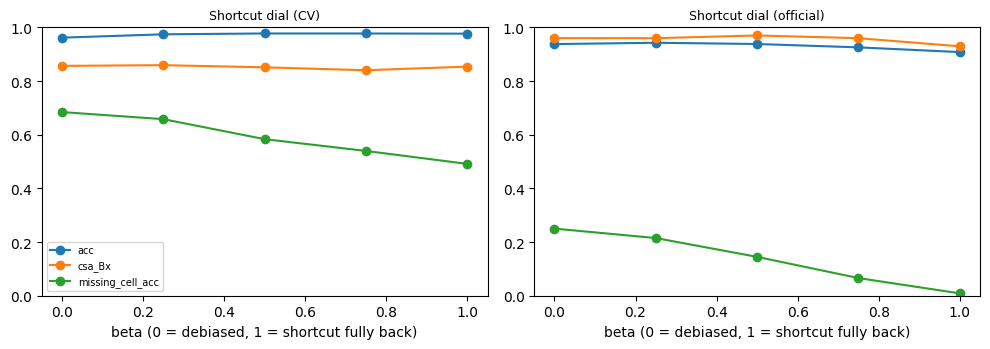

In [18]:
BETAS = [0, .25, .5, .75, 1.0]; L4 = "L4 union of all nuisance"; rows = []
lb_cv, lb_off = np.log(np.clip(PCV[L4], 1e-3, 1)), np.log(np.clip(POFF[L4], 1e-3, 1)); PO = CHOSEN["poe"]
for (bb, mt, s), e in R.items():
    if mt != PO: continue
    pm = np.zeros((N, K), np.float32)
    for r in e["runs"]: pm[r["te"]] = r["prob"].astype(np.float32)
    lp = np.log(np.clip(pm, 1e-6, 1))
    for beta in BETAS:
        c = (lp + beta*lb_cv).argmax(1) == y; rows.append(dict(arch=bb, seed=s, protocol="CV", beta=beta, acc=c.mean(), csa_Bx=c[CSS_Bx].mean(), missing_cell_acc=c[MC].mean()))
for (bb, mt, s), r in OFF.items():
    if mt != PO or r["te"].shape != te_off.shape: continue
    lp = np.log(np.clip(r["prob"].astype(np.float32), 1e-6, 1)); yo = y[te_off]
    for beta in BETAS:
        c = (lp + beta*lb_off).argmax(1) == yo; rows.append(dict(arch=bb, seed=s, protocol="official", beta=beta, acc=c.mean(), csa_Bx=c[CSSOFF_Bx[te_off]].mean(), missing_cell_acc=c[MC[te_off]].mean()))
dial = pd.DataFrame(rows)
if len(dial):
    dg = dial.groupby(["arch", "protocol", "beta"])[["acc", "csa_Bx", "missing_cell_acc"]].mean().round(3); print(f"Shortcut dial for the tuned PoE model ({LABEL[PO]}):"); print(dg.to_string()); dg.to_csv(f"{OUT}/table_shortcut_dial.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for a, pr in zip(ax, ["CV", "official"]):
        d = dial[(dial.arch == ARCH1) & (dial.protocol == pr)].groupby("beta")[["acc", "csa_Bx", "missing_cell_acc"]].mean()
        for col in d: a.plot(d.index, d[col], marker="o", label=col)
        a.set_title(f"Shortcut dial ({pr})", fontsize=9); a.set_xlabel("beta (0 = debiased, 1 = shortcut fully back)"); a.set_ylim(0, 1)
    ax[0].legend(fontsize=7); plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_dial.png", dpi=150); plt.show()

## 11. Few-shot recovery on the never-seen cell: ERM vs both operating points
**Why:** how many images from the new scanner repair the failure, and does our method need fewer? (Earlier result: our advantage is at zero shots, and ERM catches up with data. This checks it again with the tuned settings.)

cell: glio|RGB|q38|other | shot pool 38 | held-out eval 38 | rest of test 1421
                acc_cell        acc_rest        pred_notumor       
                    mean    std     mean    std         mean    std
method       k                                                     
erm          0     0.053  0.026    0.969  0.022        0.579  0.070
             4     0.377  0.132    0.981  0.004        0.298  0.066
             8     0.342  0.254    0.954  0.022        0.377  0.106
             16    0.456  0.055    0.967  0.013        0.246  0.055
             32    0.746  0.080    0.952  0.015        0.158  0.026
ipw@5        0     0.184  0.046    0.973  0.004        0.254  0.080
             4     0.149  0.066    0.963  0.027        0.368  0.070
             8     0.316  0.070    0.965  0.008        0.246  0.085
             16    0.447  0.095    0.966  0.007        0.167  0.015
             32    0.632  0.121    0.951  0.004        0.149  0.092
ipw_cfr@0.25 0     0.263  0.095    0.

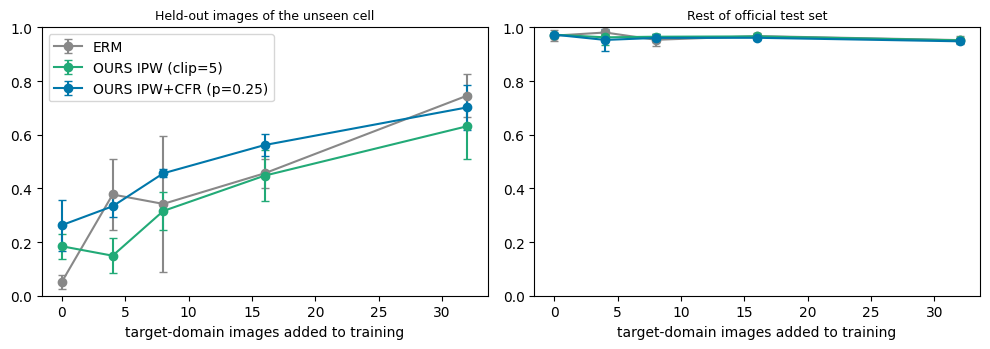

In [27]:
if len(miss):
    mcell = miss[int(np.argmax([ten[c] for c in miss]))]; idx_mc = np.where(cid == mcell)[0]; idx_mc = idx_mc[np.random.RandomState(123).permutation(len(idx_mc))]
    pool, evald = idx_mc[:len(idx_mc)//2], idx_mc[len(idx_mc)//2:]; rest = np.setdiff1d(te_off, idx_mc); print("cell:", cell_names[mcell], "| shot pool", len(pool), "| held-out eval", len(evald), "| rest of test", len(rest))
    for seed in FS_SEEDS:
        sp, tr, va, te = make_splits(seed)[5]
        for mt in [BASE] + OURS:
            for k in KS:
                f = f"{RUNS}/fs__{ARCH1}__{mt}__s{seed}__k{k}.npz"
                if os.path.exists(f): continue
                trk = np.r_[tr, np.repeat(pool[:k], 4)].astype(int) if k else tr
                LB = bias_logp(np.unique(trk), seed) if parse_mt(mt)[0] in NEEDS_LB else None
                m, _ = fit_any(ARCH1, mt, trk, va, seed, LB); pe, pr = probs(m, T0, evald).argmax(1), probs(m, T0, rest).argmax(1)
                np.savez(f, acc_cell=(pe == y[evald]).mean(), acc_rest=(pr == y[rest]).mean(), pnot=(pe == NOTU).mean()); del m; torch.cuda.empty_cache() if dev == "cuda" else None
    rows = []
    for f in glob.glob(f"{RUNS}/fs__*.npz"):
        _, bb, mt, s, k = os.path.basename(f)[:-4].split("__"); z = np.load(f); rows.append(dict(method=mt, seed=int(s[1:]), k=int(k[1:]), acc_cell=float(z["acc_cell"]), acc_rest=float(z["acc_rest"]), pred_notumor=float(z["pnot"])))
    fs = pd.DataFrame(rows); fsg = fs.groupby(["method", "k"])[["acc_cell", "acc_rest", "pred_notumor"]].agg(["mean", "std"]).round(3); print(fsg.to_string()); fsg.to_csv(f"{OUT}/table_fewshot.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for mt, c in zip([BASE] + OURS, ["#888", "#2a7", "#07a"]):
        d = fs[fs.method == mt].groupby("k")
        for a, col, t in zip(ax, ["acc_cell", "acc_rest"], ["Held-out images of the unseen cell", "Rest of official test set"]):
            mu, sd = d[col].mean(), d[col].std().fillna(0); a.errorbar(mu.index, mu, yerr=sd, marker="o", color=c, label=LABEL[mt], capsize=3); a.set_title(t, fontsize=9); a.set_xlabel("target-domain images added to training"); a.set_ylim(0, 1)
    ax[0].legend(); plt.tight_layout(); plt.savefig(f"{OUT}/fig_fewshot_recovery.png", dpi=150); plt.show()
else: print("No missing cell found in this data subset.")

## 12. Clinician review package
**Why:** metrics cannot say *why* the missing cell fails. A clinician can. The notebook writes a **blinded** pack: images with random IDs for (a) the 76 unseen-cell images, (b) up to 100 set B images, and (c) a control group of main-source images of the same class. Reviewers see only the image and the template, never the dataset label. Send `outputs/clinician/` (images, contact sheets and `clinician_review_template.csv`) to one or two clinicians and keep `clinician_key.csv` private. When ratings come back, set `CLIN_CSVS` to the completed file(s) and rerun the analysis cell.

**Ask the reviewers for:** MR sequence (T1, T1 contrast, T2, FLAIR, CT, other, unsure), plane (axial, coronal, sagittal, unsure), tumour visible (yes, no, unsure), tumour type (glioma, meningioma, pituitary, none, unsure), image quality (good, ok, poor), notes. Images are from a public dataset and contain no patient identifiers.

In [20]:
CLIN = f"{OUT}/clinician"; os.makedirs(CLIN, exist_ok=True); rc = np.random.RandomState(7); groups = []
if len(miss):
    cls_u = miss[0]//NFG; idx_u = np.where(MC)[0]; groups.append(("unseen_cell", idx_u))
    ctrl = rc.choice(np.where((y == cls_u) & ~MF)[0], min(len(idx_u), int(((y == cls_u) & ~MF).sum())), replace=False); groups.append(("control_main_source", ctrl))
poolB = np.setdiff1d(np.where(CSS_Bx | CSS_Bmf)[0], np.where(MC)[0])
if len(poolB): groups.append(("set_B", rc.choice(poolB, min(100, len(poolB)), replace=False)))
allrows = [(g, int(i)) for g, ix in groups for i in ix]; order_ = rc.permutation(len(allrows)); key = []
for k_, j in enumerate(order_):
    g, i = allrows[j]; iid = f"R{k_+1:03d}"
    with Image.open(df.path[i]) as im: im = im.convert("L"); sc_ = 384/max(im.size); im.resize((max(1, int(im.size[0]*sc_)), max(1, int(im.size[1]*sc_))), Image.BILINEAR).save(f"{CLIN}/{iid}.png")
    key.append(dict(image_id=iid, idx=i, path=df.path[i], true_label=classes[y[i]], group=g, fmt=df.fg[i]))
key = pd.DataFrame(key); key.to_csv(f"{CLIN}/clinician_key_PRIVATE.csv", index=False)
pd.DataFrame(dict(image_id=key.image_id, mr_sequence="", plane="", tumour_visible="", tumour_type="", image_quality="", notes="")).to_csv(f"{CLIN}/clinician_review_template.csv", index=False)
for s0 in range(0, len(key), 20):
    fig, ax = plt.subplots(4, 5, figsize=(12, 10))
    for a, (_, r) in zip(ax.ravel(), key.iloc[s0:s0+20].iterrows()): a.imshow(Image.open(f"{CLIN}/{r.image_id}.png"), cmap="gray"); a.set_title(r.image_id, fontsize=8); a.axis("off")
    for a in ax.ravel(): a.axis("off")
    plt.tight_layout(); plt.savefig(f"{CLIN}/contact_sheet_{s0//20 + 1:02d}.png", dpi=90); plt.close()
print("clinician package:", len(key), "images |", key.group.value_counts().to_dict(), "| folder:", CLIN)

clinician package: 252 images | {'set_B': 100, 'control_main_source': 76, 'unseen_cell': 76} | folder: outputs/clinician


In [21]:
if CLIN_CSVS and os.path.exists(CLIN_CSVS[0]):
    rv = pd.read_csv(CLIN_CSVS[0]).merge(key, on="image_id"); rv = rv.replace({"": np.nan})
    for col in ("mr_sequence", "plane"): print(f"\n{col} by group:"); print(pd.crosstab(rv.group, rv[col].fillna("missing")).to_string())
    ok_ = rv.tumour_type.notna() & (rv.tumour_type != "unsure"); tl = rv.tumour_type.replace({"none": "notumor"})
    print(f"\nclinician tumour type vs dataset label: agreement {(tl[ok_] == rv.true_label[ok_]).mean():.3f} (n={int(ok_.sum())}), Cohen kappa {cohen_kappa_score(tl[ok_], rv.true_label[ok_]):.3f}")
    print("label disagreement by group:"); print((tl[ok_] != rv.true_label[ok_]).groupby(rv.group[ok_]).mean().round(3).to_string())
    preds = {}
    for mt in (BASE, OURS[1]):
        if (ARCH1, mt, 0) in OFF: preds[mt] = dict(zip(OFF[(ARCH1, mt, 0)]["te"], OFF[(ARCH1, mt, 0)]["pred"]))
    u = rv[rv.group == "unseen_cell"].copy()
    for mt, pm in preds.items(): u[f"ok_{mt}"] = [pm.get(i, -1) == y[i] for i in u.idx]; u[f"det_{mt}"] = [pm.get(i, -1) != NOTU for i in u.idx]
    if len(preds):
        print("\nUNSEEN CELL: model accuracy and tumour detection by clinician-rated MR sequence"); print(u.groupby(u.mr_sequence.fillna("missing"))[[c for c in u.columns if c.startswith(("ok_", "det_"))]].agg(["mean", "count"]).round(3).to_string())
    if len(CLIN_CSVS) > 1 and os.path.exists(CLIN_CSVS[1]):
        r2 = pd.read_csv(CLIN_CSVS[1]).merge(rv[["image_id"]], on="image_id"); m2 = rv.merge(r2, on="image_id", suffixes=("", "_2"))
        for col in ("mr_sequence", "plane", "tumour_type"): k_ok = m2[col].notna() & m2[col + "_2"].notna(); print(f"inter-rater kappa {col}: {cohen_kappa_score(m2[col][k_ok], m2[col + '_2'][k_ok]):.3f} (n={int(k_ok.sum())})")
else: print("No clinician ratings yet. Send the clinician folder to 1 or 2 reviewers, then set CLIN_CSVS to the completed csv path(s) and rerun this cell.")

No clinician ratings yet. Send the clinician folder to 1 or 2 reviewers, then set CLIN_CSVS to the completed csv path(s) and rerun this cell.


## 13. External validation (strongest evidence, needs other datasets)
**Why:** reviewers at good journals ask whether the gains hold on data from another source. Add one or more public brain MRI datasets as Kaggle inputs with **one folder per class** (names containing glioma, meningioma, pituitary, notumor, or binary names such as yes/no or tumor/normal) and set `EXT_ROOTS` (comma separated). Choose sources that are **different from the Kaggle dataset's origins**, and check each license.

**What the notebook does for every external dataset:** (1) finds images that duplicate the training data (perceptual hash + correlation) and **removes them**; (2) trains a nuisance probe on the training data and reports how well it solves the external set (do the shortcuts transfer?); (3) builds an **external counter-shortcut set** (probe confidently wrong); (4) tests every saved model with no retraining and reports tumour detection (sensitivity, specificity, AUC), 4-class accuracy where labels allow, and counter-shortcut accuracy; (5) gives paired bootstrap differences between our method and the others. Models trained in v9 were saved for seed 0 only; models from new runs are saved for every seed.

In [22]:
EXT = {}
def lab_of(n):
    n = n.lower()
    for k in ("glioma", "meningioma", "pituitary"):
        if k in n and k in classes: return classes.index(k)
    if any(t in n for t in ("notumor", "no_tumor", "no tumor", "no_tumour", "normal", "healthy", "negative")) or n in ("no", "non"): return NOTU
    if any(t in n for t in ("tumor", "tumour", "yes", "positive", "pred")): return -1             # tumour of unspecified type
    return None
if EXT_ROOTS:
    clfA = hgb().fit(FU[tr_off], y[tr_off])
    for root in EXT_ROOTS:
        files = [f for f in glob.glob(f"{root}/**/*", recursive=True) if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))]
        labs = [lab_of(os.path.basename(os.path.dirname(f))) for f in files]; ki = [i for i, l in enumerate(labs) if l is not None]
        files, ey = [files[i] for i in ki], np.array([labs[i] for i in ki]); name = os.path.basename(root.rstrip("/")) or root
        if len(files) == 0: print(name, ": no labelled images found (check folder names)"); continue
        D = [describe(f) for f in tqdm(files, desc=name)]
        ph = np.array([d["ph"] for d in D], dtype=np.uint64); sm = np.stack([d["sm"] for d in D]).reshape(len(D), -1); sm = sm - sm.mean(1, keepdims=True); sm /= (np.linalg.norm(sm, axis=1, keepdims=True) + 1e-8)
        dup = np.zeros(len(D), bool)
        for i0 in range(0, len(D), 64):
            ii, jj = np.where(pc(ph[i0:i0+64, None] ^ PH[None, :]) <= 4)
            for a_, b_ in zip(ii, jj):
                if sm[i0 + a_] @ Sf[b_] >= .98: dup[i0 + a_] = True
        F0e = np.c_[[d["md"] == "RGB" for d in D], [d["q0"] for d in D]].astype(float); F1e = np.c_[[d["w"] for d in D], [d["h"] for d in D], [d["w"]/d["h"] for d in D], [d["kb"]*1024/(d["w"]*d["h"]) for d in D]]
        FUe = np.c_[F0e, F1e, np.stack([d["f2"] for d in D]), np.stack([d["f3"] for d in D])]; pe = pfull(clfA, FUe); tb = ey != NOTU; ptum = 1 - pe[:, NOTU]; ptrue = np.where(tb, ptum, 1 - ptum)
        kp = ~dup; EXT[name] = dict(xr=np.stack([d["xr"] for d in D]), ey=ey, keep=kp, cs=ptrue < .10)
        print(f"[{name}] {len(files)} images ({int(tb.sum())} tumour, {int((~tb).sum())} no tumour) | duplicates of the training data REMOVED: {int(dup.sum())} | evaluated: {int(kp.sum())}")
        print(f"   nuisance probe on this external set: binary accuracy {(((ptum > .5) == tb)[kp]).mean():.3f} (do shortcuts transfer?) | external counter-shortcut images: {int((EXT[name]['cs'] & kp).sum())} | formats: {pd.Series([d['md'] + '/' + ('q' + str(d['q0'])) for d in D]).value_counts().head(3).to_dict()}")
else: print("EXT_ROOTS not set: add other datasets as Kaggle inputs and set EXT_ROOTS (comma separated), then rerun sections 13 and 14.")

EXT_ROOTS not set: add other datasets as Kaggle inputs and set EXT_ROOTS (comma separated), then rerun sections 13 and 14.


In [23]:
ext_rows, ext_cor = [], {}
def model_files(bb, mt):
    out = [(s, f"{MODELS}/{bb}__{mt}__off__s{s}.pt") for s in range(10) if os.path.exists(f"{MODELS}/{bb}__{mt}__off__s{s}.pt")]
    leg = f"{MODELS}/{bb}__{mt}__off.pt"
    if os.path.exists(leg) and not any(s == 0 for s, _ in out): out.append((0, leg))
    return out
def load_model(bb, f):
    m = Net(bb).to(dev); sd = torch.load(f, map_location=dev); m.load_state_dict({k: (v.float() if torch.is_floating_point(v) else v) for k, v in sd.items()}); return m
for name, E_ in EXT.items():
    kp = E_["keep"]; ET = torch.as_tensor(((E_["xr"][kp].astype(np.float32)/255 - .45)/.225)).half().to(dev); ey = E_["ey"][kp]; cs = E_["cs"][kp]; tb = ey != NOTU
    for bb in ARCHS:
        for mt in METHODS:
            for s, f in model_files(bb, mt):
                m = load_model(bb, f); p = predx(m, ET); pred = p.argmax(1); cb = ((pred != NOTU) == tb); spc = ey >= 0
                ext_rows.append(dict(dataset=name, arch=bb, method=mt, seed=s, det_sens=(pred[tb] != NOTU).mean() if tb.any() else np.nan, det_spec=(pred[~tb] == NOTU).mean() if (~tb).any() else np.nan,
                                     auc=roc_auc_score(tb, 1 - p[:, NOTU]) if tb.any() and (~tb).any() else np.nan, csa_ext=cb[cs].mean() if cs.any() else np.nan, acc_4class=(pred[spc] == ey[spc]).mean() if spc.any() else np.nan))
                ext_cor[(name, bb, mt, s)] = cb.astype(float); del m
if ext_rows:
    ex_df = pd.DataFrame(ext_rows); ex_df["det_bal"] = (ex_df.det_sens + ex_df.det_spec)/2; ex_df.to_csv(f"{OUT}/per_model_external.csv", index=False)
    et = ex_df.groupby(["dataset", "arch", "method"])[["det_bal", "det_sens", "det_spec", "auc", "csa_ext", "acc_4class"]].agg(["mean"]).droplevel(1, axis=1).round(3); et.index = et.index.set_levels([LABEL[m] for m in et.index.levels[2]], level=2) if False else et.index
    print("EXTERNAL VALIDATION (mean over available seeds; csa_ext = accuracy on external counter-shortcut images):"); print(et.to_string()); et.to_csv(f"{OUT}/table_external.csv")
    rb = np.random.RandomState(0); rows = []
    for name in EXT:
        kp = EXT[name]["keep"]; ey = EXT[name]["ey"][kp]; tb = ey != NOTU; nn_ = int(kp.sum()); IXe = rb.randint(0, nn_, (500, nn_)); bal = lambda c: np.array([(c[ix][tb[ix]].mean() + c[ix][~tb[ix]].mean())/2 if tb[ix].any() and (~tb[ix]).any() else np.nan for ix in IXe])
        for bb in ARCHS:
            cvec = {mt: np.mean([v for (n_, b_, m_, s_), v in ext_cor.items() if (n_, b_, m_) == (name, bb, mt)], 0) for mt in METHODS if any((n_, b_, m_) == (name, bb, mt) for (n_, b_, m_, s_) in ext_cor)}
            for op in OURS:
                if op not in cvec: continue
                for mt in cvec:
                    if mt == op: continue
                    dd = bal(cvec[op]) - bal(cvec[mt]); rows.append(dict(dataset=name, arch=bb, ours=LABEL[op], vs=LABEL[mt], det_bal_diff=f"{np.nanmean(dd):+.3f} [{np.nanpercentile(dd,2.5):+.3f},{np.nanpercentile(dd,97.5):+.3f}]"))
    ext_diff = pd.DataFrame(rows); print("\nOurs minus other method, balanced tumour-detection accuracy (image bootstrap):"); print(ext_diff.to_string()); ext_diff.to_csv(f"{OUT}/table_external_diffs.csv", index=False)
else: print("No external results yet (set EXT_ROOTS, rerun the previous cell and this one).")

No external results yet (set EXT_ROOTS, rerun the previous cell and this one).


## 14. Paper results file
**Why:** this cell writes `paper_results_summary.md`: every headline number with its interval, and whether each claim is supported by the data (confidence interval above zero). Use it as the source for the Results section so no number is typed by hand.

In [24]:
L = []; sup = lambda a: "SUPPORTED" if np.percentile(a, 2.5) > 0 else "not supported (interval includes 0)"
L.append("# Results summary (auto-generated)\n")
L.append("## C1. Most of the benchmark can be solved without tumour anatomy")
for nm_, r in ladder.iterrows(): L.append(f"- {nm_}: CV accuracy {r.cv_acc:.3f}, official split {r.off_acc:.3f}")
L.append(f"- Share of images solved by the nuisance union probe (CV): {(pu.argmax(1) == y).mean():.3f}")
L.append("\n## C2. Headline accuracy hides a reliability gap (ERM)")
for bb in ARCHS:
    e = off[(off.arch == bb) & (off.method == "erm")]
    if len(e): L.append(f"- {bb}: official accuracy {e.acc.mean():.3f}; independent counter-shortcut B-x {e.csa_Bx.mean():.3f}; unseen-cell accuracy {e.missing_cell_acc.mean():.3f}; unseen-cell tumour detection {e.missing_cell_detect.mean():.3f}")
L.append("\n## C3. Probe-guided debiasing vs ERM (official split, duplicate-aware bootstrap)")
for bb in ARCHS:
    for op in OURS:
        if (bb, op) in bres and (bb, "erm") in bres:
            for k in ("off_csa_Bx", "off_acc", "off_missing_detect"):
                if k in bres[(bb, op)] and k in bres[(bb, "erm")]: dd = bres[(bb, op)][k] - bres[(bb, "erm")][k]; L.append(f"- {bb}, {LABEL[op]}, {k}: {dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}] {sup(dd)}")
L.append("\n## C4. Comparison with 5 tuned literature methods (7-metric ranking, set A excluded)")
if "allrk" in globals(): L.append(allrk.round(2).to_string().replace("\n", "\n    ")); L.append("- Pareto front (official accuracy vs independent reliability): " + str({b: [LABEL[m] for m in FRONT[b]] for b in FRONT}))
L.append("\n## C5. Expert ablation (ConvNeXt-T, official split)")
if "abl_df" in globals(): L.append(abl_df[[c for c in abl_df.columns if c in ("variant", "off_csa_Bx", "off_missing_detect", "gain_vs_control_off_csa_Bx")]].to_string(index=False))
L.append("\n## C6. External validation")
L.append(ex_df.groupby(["dataset", "arch", "method"])[["det_bal", "auc", "csa_ext"]].mean().round(3).to_string() if "ex_df" in globals() else "- not run yet (set EXT_ROOTS)")
L.append("\n## C7. Clinician review")
L.append("- completed ratings analysed above" if CLIN_CSVS and os.path.exists(CLIN_CSVS[0]) else "- not run yet (send the clinician folder, set CLIN_CSVS)")
L.append("\n## Limits to state\n- probes are proxies, not proof of what a network uses; 2D slices and no patient IDs; the unseen cell has 76 images; settings tuned on ConvNeXt-T and reused; CV on 1 seed for ResNet50 and EfficientNet-B0; validation images from Training cannot reveal the domain shift.")
open(f"{OUT}/paper_results_summary.md", "w").write("\n".join(L)); print("\n".join(L)[:6000])

# Results summary (auto-generated)

## C1. Most of the benchmark can be solved without tumour anatomy
- L0 metadata (mode, JPEG table): CV accuracy 0.516, official split 0.460
- L1 geometry (size, aspect, bytes/px): CV accuracy 0.661, official split 0.594
- L2 contrast histogram only: CV accuracy 0.851, official split 0.786
- L3 background only: CV accuracy 0.901, official split 0.824
- L4 union of all nuisance: CV accuracy 0.936, official split 0.840
- B independent (thumbnail + noise/frequency): CV accuracy 0.867, official split 0.788
- Share of images solved by the nuisance union probe (CV): 0.936

## C2. Headline accuracy hides a reliability gap (ERM)
- convnext_tiny: official accuracy 0.924; independent counter-shortcut B-x 0.980; unseen-cell accuracy 0.083; unseen-cell tumour detection 0.496
- resnet50: official accuracy 0.921; independent counter-shortcut B-x 0.960; unseen-cell accuracy 0.096; unseen-cell tumour detection 0.509
- efficientnet_b0: official accuracy 0.890; indepen

In [25]:
with open(f"{OUT}/tables.tex", "w") as fh:
    for nm_, t in [("ladder", ladder), ("ours_vs_all", vs_df), ("showdown_rank", allrk.round(2)), ("expert_ablation", abl_df)]: fh.write(f"% {nm_}\n" + t.to_latex() + "\n")
print("Saved:", sorted(os.listdir(OUT)))

Saved: ['cache_v8_N6997.npz', 'clinician', 'config.json', 'fig_css_B_examples.png', 'fig_expert_ablation.png', 'fig_fewshot_recovery.png', 'fig_pareto.png', 'fig_shortcut_dial.png', 'fig_shortcut_ladder.png', 'fig_showdown_rank.png', 'models', 'paper_results_summary.md', 'per_seed_cv.csv', 'per_seed_off.csv', 'runs', 'table_ci.csv', 'table_cv.csv', 'table_expert_ablation.csv', 'table_explained_by_shortcut.csv', 'table_fewshot.csv', 'table_missing_cell_predictions.csv', 'table_official.csv', 'table_ours_vs_all.csv', 'table_shortcut_dial.csv', 'table_shortcut_ladder.csv', 'table_showdown_rank.csv', 'table_tuning.csv', 'tables.tex']


## 15. How this maps to the thesis
- **Chapter 1, Audit:** section 3 (ladder, families A and B), SSF from section 4.
- **Chapter 2, Honest evaluation:** counter-shortcut accuracy on set A, the independent set B, and the domain-controlled sets B-x and B-mf (sections 4, 4b, 7).
- **Chapter 3, Missing cell:** section 1 table, unseen-cell results, recovery curve (section 11), clinician review (section 12).
- **Chapter 4, Methods and comparison:** sections 5 to 10 (equal-budget tuning, 5 literature methods vs 2 of ours, 3 architectures with 3 seeds on the official split, ranking without set A, Pareto front, dial) and the expert ablation (sections 6b, 8b).
- **Chapter 5, Validation:** external datasets (section 13) and the clinician package.

**Limits to state:** probes are proxies, not proof of what the network uses; 2D slices and no patient IDs; the unseen cell has 76 images; settings tuned on ConvNeXt-T and reused for the other two architectures; validation images from Training cannot reveal the domain shift; external results depend on the datasets you add.